In [144]:
# in this notebook, we load two cluster assignments, create dictionaries using the shared examples only based on their keys, and measure their similarities.

In [145]:
# let's load a few important packages for checking the cluster similarities
import numpy as np
import pandas as pd
import os
import sys
import json
from collections import Counter
# from sklearn.metrics import adjusted_rand_score
# from sklearn.metrics import normalized_mutual_info_score
# from sklearn.metrics import adjusted_mutual_info_score
# from sklearn.metrics import fowlkes_mallows_score
# from sklearn.metrics import silhouette_score
# from sklearn.metrics import calinski_harabasz_score
# from sklearn.metrics import davies_bouldin_score
# from sklearn.metrics import pairwise_distances
# from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import csv

In [146]:
# let's load the target/ground-truth cluster assignments. it's in `root_id_type_dict.pkl` file.
import pickle
root_id_type_dict = pickle.load(open('root_id_type_dict.pkl', 'rb'))

In [147]:
# let's load the estimated cluster assignments from `cluster_assignment_dict.npy`
pca_cluster_assignment_dict = np.load('pca_cluster_assignment_dict_tuned_2.npy', allow_pickle=True).item()

with open("root_id_to_index_mapping.json", "r") as f:
    rid2idx = json.load(f)                     
idx2rid = {int(v): int(k) for k, v in rid2idx.items()}

lv_dict_idx = np.load('vmog_runs/vmog_cluster_assignment_dict_tuned_2.npy', allow_pickle=True).item()

lv_cluster_assignment_dict = { idx2rid[int(idx)]: int(lbl)
                 for idx, lbl in lv_dict_idx.items()
                 if int(idx) in idx2rid }

In [148]:
sbm_cluster_assignment_dict = np.load('runs_sbm/sbm_0/cluster_assignment_dict.npy', allow_pickle=True).item()

In [149]:
# first, let's create a dictionary of the keys of `root_id_type_dict` mapped to integer indices.
root_id_type_dict_keys = list(root_id_type_dict.keys())
root_id_type_dict_keys_dict = {root_id_type_dict_keys[i]: i for i in range(len(root_id_type_dict_keys))}

In [150]:
list(pca_cluster_assignment_dict.keys())[1]

720575940631267655

In [151]:
shared_root_ids = list(set(root_id_type_dict.keys())
                       .intersection(set(pca_cluster_assignment_dict.keys()))
                                     .intersection(set(lv_cluster_assignment_dict.keys()))
                                        .intersection(set(sbm_cluster_assignment_dict.keys())))

In [152]:
root_id_type_dict_cluster_strings = list(set(root_id_type_dict.values()))
cluster_string_to_cid = dict([(cluster_string, cid) 
                              for cid, cluster_string
                              in enumerate(root_id_type_dict_cluster_strings)])
cid_to_cluster_string = dict([(cid, cluster_string) 
                              for cluster_string, cid
                              in cluster_string_to_cid.items()])
print(f'there are {len(cluster_string_to_cid)} unique cluster assignments in the ground-truth data.')

there are 743 unique cluster assignments in the ground-truth data.


In [153]:
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
pca_assignments = np.array([pca_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
lv_assignments = np.array([lv_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
sbm_assignments = np.array([sbm_cluster_assignment_dict[root_id] for root_id in shared_root_ids])


In [154]:
gt_assignments

array([466, 225, 225, ..., 618, 387, 608], shape=(95145,))

In [155]:
print(len(gt_assignments))

95145


In [156]:
gt_assignments[:10], pca_assignments[:10], lv_assignments[:10], sbm_assignments[:10]

(array([466, 225, 225, 387, 115, 554, 225, 202, 691, 129]),
 array([1056,  431,  843,   11,   35,  608,  820,  723,  354,  934]),
 array([720, 772, 315, 528, 761, 628, 557, 179, 278,  78]),
 array([ 978,  360,  808,  273,  166,   67,  772, 1252, 1544, 1267]))

In [157]:
# tuned pca k means
gt_assignments[:10], pca_assignments[:10], lv_assignments[:10]

(array([466, 225, 225, 387, 115, 554, 225, 202, 691, 129]),
 array([1056,  431,  843,   11,   35,  608,  820,  723,  354,  934]),
 array([720, 772, 315, 528, 761, 628, 557, 179, 278,  78]))

In [158]:
print(f'# of unique cluster assignments in the ground-truth data: {len(np.unique(gt_assignments))}')
print(f'# of unique cluster assignments in the PCA data: {len(np.unique(pca_assignments))}')
print(f'# of unique cluster assignments in the GMM data: {len(np.unique(lv_assignments))}')
print(f'# of unique cluster assignments in the SBM data: {len(np.unique(sbm_assignments))}')

# of unique cluster assignments in the ground-truth data: 743
# of unique cluster assignments in the PCA data: 1062
# of unique cluster assignments in the GMM data: 542
# of unique cluster assignments in the SBM data: 1248


In [159]:
# tune pca k means
print(f'# of unique cluster assignments in the ground-truth data: {len(np.unique(gt_assignments))}')
print(f'# of unique cluster assignments in the PCA data: {len(np.unique(pca_assignments))}')
print(f'# of unique cluster assignments in the LV data: {len(np.unique(lv_assignments))}')

# of unique cluster assignments in the ground-truth data: 743
# of unique cluster assignments in the PCA data: 1062
# of unique cluster assignments in the LV data: 542


In [160]:
# create a random assignment by randomly permuting `target_assignment`
random_assignment_optimistic = np.random.permutation(gt_assignments)
random_assignment_pessimistic = np.random.randint(0, np.unique(gt_assignments).shape[0], gt_assignments.shape[0])

In [161]:
print(f'# of unique cluster assignments in the random assignment (optimistic): {len(np.unique(random_assignment_optimistic))}')
print(f'# of unique cluster assignments in the random assignment (pessimistic): {len(np.unique(random_assignment_pessimistic))}')

# of unique cluster assignments in the random assignment (optimistic): 743
# of unique cluster assignments in the random assignment (pessimistic): 743


In [162]:
def confusion_matrix(X, Y):
    assert len(X) == len(Y)
    print(len(X))
    unique_x = np.unique(X)
    unique_y = np.unique(Y)
    
    x_dict = dict([(unique_x[i], i) for i in range(len(unique_x))])
    y_dict = dict([(unique_y[i], i) for i in range(len(unique_y))])

    confusion_matrix = np.zeros((len(unique_x), len(unique_y)))
    print(x_dict[X[1]])
    for i in range(len(X)):
        confusion_matrix[x_dict[X[i]], y_dict[Y[i]]] += 1

    return confusion_matrix

In [163]:
from scipy.optimize import linear_sum_assignment

def compare_two_assignments(assignment_A, assignment_B):
    confusion_matrix_value = confusion_matrix(assignment_A, assignment_B)

    # Step 2: Align clusters using the Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(confusion_matrix_value, maximize=True)
    score = confusion_matrix_value[row_ind, col_ind].sum()

    # Step 3: Apply log scale to the score
    # log_score = np.log(score)  # log(1 + score)

    # Step 4: Reorder columns of confusion matrix to align clusters
    aligned_confusion_matrix = confusion_matrix_value[:, col_ind]

    return score, aligned_confusion_matrix

In [164]:
# Variation of Information

In [165]:
pca_assignments

array([1056,  431,  843, ...,  632,  623,  504], shape=(95145,))

In [166]:
# compare the ground-truth assignment against (a) PCA assignment, (b) LV assignment, (c) random assignment (optimistic), and (d) random assignment (pessimistic)
score_pca, _ = compare_two_assignments(gt_assignments, pca_assignments)
score_lv, _ = compare_two_assignments(gt_assignments, lv_assignments)
score_sbm, _ = compare_two_assignments(gt_assignments, sbm_assignments)
score_random_optimistic, _ = compare_two_assignments(gt_assignments, random_assignment_optimistic)
score_random_pessimistic, _ = compare_two_assignments(gt_assignments, random_assignment_pessimistic)

print(f'PCA: {score_pca}')
print(f'LV: {score_lv}')
print(f'SBM: {score_sbm}')
print(f'Random (optimistic): {score_random_optimistic}')
print(f'Random (pessimistic): {score_random_pessimistic}')

95145
225
95145
225
95145
225
95145
225
95145
225
PCA: 6545.0
LV: 4276.0
SBM: 15360.0
Random (optimistic): 2272.0
Random (pessimistic): 1308.0


In [167]:
# check the similarity between PCA and LV assignments
score_pca_lv, _ = compare_two_assignments(pca_assignments, lv_assignments)

print(f"PCA vs. LV: {score_pca_lv}")

95145
356
PCA vs. LV: 2087.0


In [168]:
# tuned pca k means
# check the similarity between PCA and LV assignments
score_pca_lv, _ = compare_two_assignments(pca_assignments, lv_assignments)

print(f"PCA vs. LV: {score_pca_lv}")

95145
356
PCA vs. LV: 2087.0


In [169]:
from matplotlib import pyplot as plot

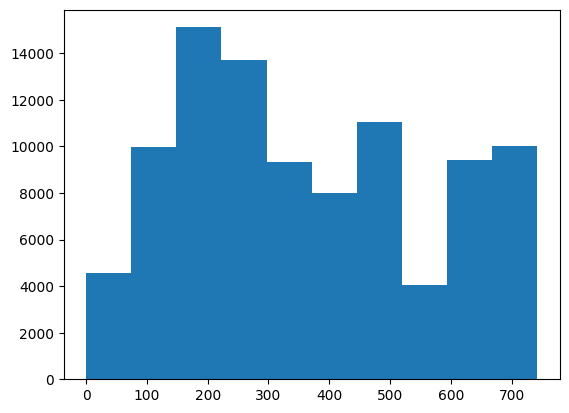

In [170]:
plot.figure()

plot.hist(gt_assignments)

plot.show()

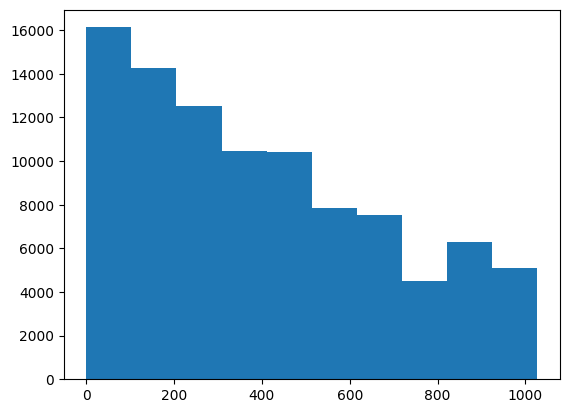

In [171]:
plot.figure()

plot.hist(lv_assignments)

plot.show()

95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
Runs found : 48
Mean score : 6794.9792
95% CI     : [6071.4000, 7807.6500]


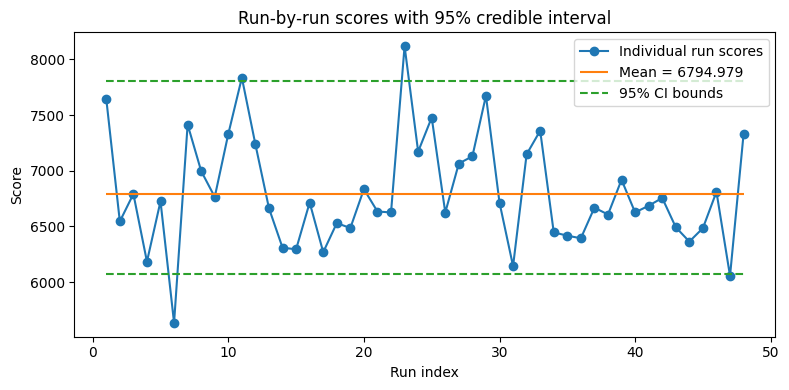

In [172]:
scores = []

for i in range(48):
    pca_cluster_assignment_dict = np.load(f"runs/pca_cluster_assignment_dict_tuned_{i+1}.npy", allow_pickle=True).item()
    shared_root_ids = list(set(root_id_type_dict.keys())
                       .intersection(set(pca_cluster_assignment_dict.keys())))
    gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
    pca_assignments = np.array([pca_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
    score_pca, _ = compare_two_assignments(gt_assignments, pca_assignments)
    scores.append(score_pca)
    
scores = np.array(scores)
mean_score = scores.mean()
lower, upper = np.percentile(scores, [2.5, 97.5])

print(f"Runs found : {len(scores)}")
print(f"Mean score : {mean_score:.4f}")
print(f"95% CI     : [{lower:.4f}, {upper:.4f}]")

runs = np.arange(1, len(scores) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs, scores, 'o-', label="Individual run scores")
plt.hlines(mean_score, runs[0], runs[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score:.3f}")
plt.hlines([lower, upper], runs[0], runs[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

In [173]:
std_score = scores.std(ddof=1)
std_score

np.float64(494.1207746920478)

95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
Runs found : 49
Mean score : 17527.1429
95% CI     : [15033.6000, 21537.2000]


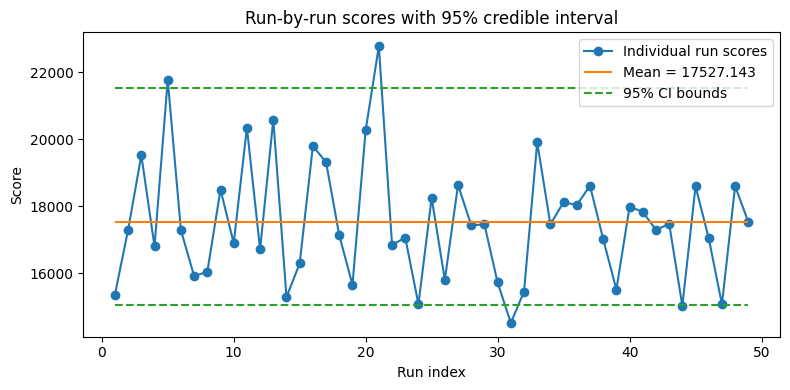

In [174]:
scores_sbm = []

for i in range(49):
    sbm_cluster_assignment_dict = np.load(f"runs_sbm/sbm_{i}/cluster_assignment_dict.npy", allow_pickle=True).item()
    shared_root_ids = list(set(root_id_type_dict.keys())
                       .intersection(set(sbm_cluster_assignment_dict.keys())))
    gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
    sbm_assignments = np.array([sbm_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
    score_sbm, _ = compare_two_assignments(gt_assignments, sbm_assignments)
    scores_sbm.append(score_sbm)
    
scores_sbm = np.array(scores_sbm)
mean_score = scores_sbm.mean()
lower_sbm, upper_sbm = np.percentile(scores_sbm, [2.5, 97.5])

print(f"Runs found : {len(scores_sbm)}")
print(f"Mean score : {mean_score:.4f}")
print(f"95% CI     : [{lower_sbm:.4f}, {upper_sbm:.4f}]")

runs = np.arange(1, len(scores_sbm) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs, scores_sbm, 'o-', label="Individual run scores")
plt.hlines(mean_score, runs[0], runs[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score:.3f}")
plt.hlines([lower_sbm, upper_sbm], runs[0], runs[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

In [175]:
std_score = scores_sbm.std(ddof=1)
std_score

np.float64(1827.5729237616392)

In [176]:
np.log(20000)

np.float64(9.903487552536127)

95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
Runs found : 15
Mean score : 5244.4667
95% CI     : [4283.0000, 7240.0000]


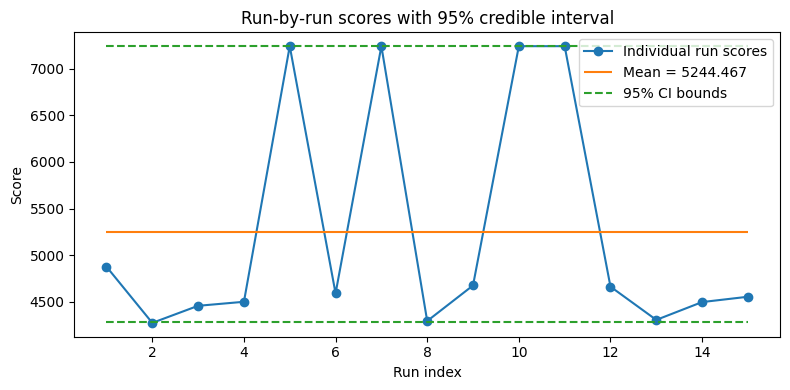

In [177]:
scores_vmog = []

for i in range(15):
    lv_dict_idx = np.load(f"vmog_runs/vmog_cluster_assignment_dict_tuned_{i+1}.npy", allow_pickle=True).item()

    vmog_cluster_assignment_dict = { idx2rid[int(idx)]: int(lbl)
                    for idx, lbl in lv_dict_idx.items()
                    if int(idx) in idx2rid }

    gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
    vmog_assignments = np.array([vmog_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
    score_vmog, _ = compare_two_assignments(gt_assignments, vmog_assignments)
    scores_vmog.append(score_vmog)
    
scores_vmog = np.array(scores_vmog)
mean_score_vmog = scores_vmog.mean()
lower_vmog, upper_vmog = np.percentile(scores_vmog, [2.5, 97.5])

print(f"Runs found : {len(scores_vmog)}")
print(f"Mean score : {mean_score_vmog:.4f}")
print(f"95% CI     : [{lower_vmog:.4f}, {upper_vmog:.4f}]")

runs_vmog = np.arange(1, len(scores_vmog) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs_vmog, scores_vmog, 'o-', label="Individual run scores")
plt.hlines(mean_score_vmog, runs_vmog[0], runs_vmog[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score_vmog:.3f}")
plt.hlines([lower_vmog, upper_vmog], runs_vmog[0], runs_vmog[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

In [178]:
std_score = scores_vmog.std(ddof=1)
std_score

np.float64(1255.274350585598)

95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
95145
225
Runs found : 48
Mean score : 2274.4167
9

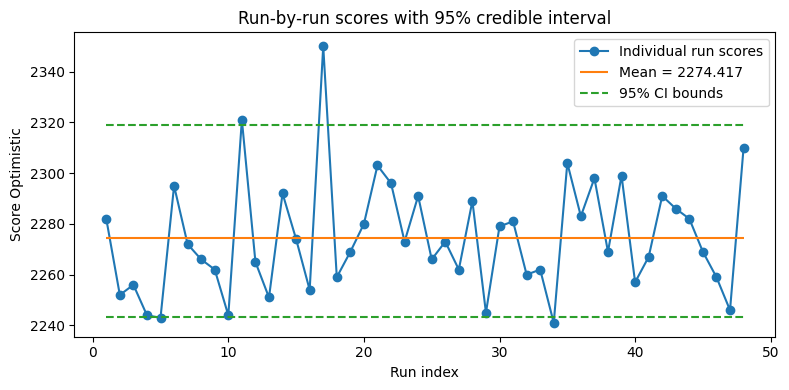

Runs found : 48
Mean score : 1281.5625
95% CI     : [1265.5250, 1297.8250]


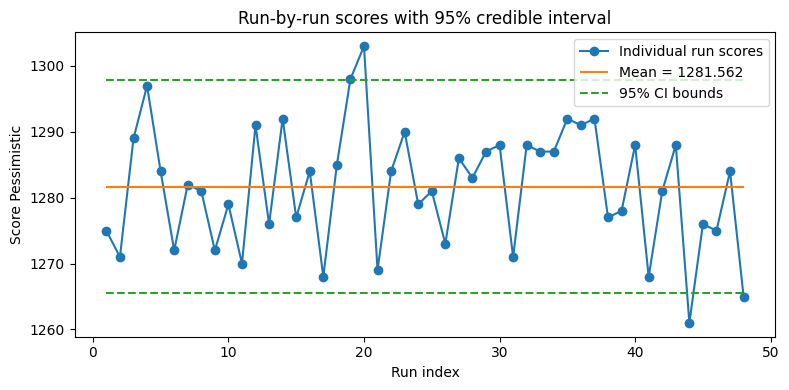

In [179]:
scores_optimistic = []
scores_pessimistic = []

for i in range(48):
    # create a random assignment by randomly permuting `target_assignment`
    random_assignment_optimistic = np.random.permutation(gt_assignments)
    random_assignment_pessimistic = np.random.randint(0, np.unique(gt_assignments).shape[0], gt_assignments.shape[0])
    
    gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[root_id]] for root_id in shared_root_ids])
    
    score_optimistic, _ = compare_two_assignments(gt_assignments, random_assignment_optimistic)
    scores_optimistic.append(score_optimistic)
    
    score_pessimistic, _ = compare_two_assignments(gt_assignments, random_assignment_pessimistic)
    scores_pessimistic.append(score_pessimistic)
    
scores_optimistic = np.array(scores_optimistic)
mean_score_optimistic = scores_optimistic.mean()
lower_optimistic, upper_optimistic = np.percentile(scores_optimistic, [2.5, 97.5])

print(f"Runs found : {len(scores_optimistic)}")
print(f"Mean score : {mean_score_optimistic:.4f}")
print(f"95% CI     : [{lower_optimistic:.4f}, {upper_optimistic:.4f}]")

runs_optimistic = np.arange(1, len(scores_optimistic) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs_optimistic, scores_optimistic, 'o-', label="Individual run scores")
plt.hlines(mean_score_optimistic, runs_optimistic[0], runs_optimistic[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score_optimistic:.3f}")
plt.hlines([lower_optimistic, upper_optimistic], runs_optimistic[0], runs_optimistic[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score Optimistic")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

scores_pessimistic = np.array(scores_pessimistic)
mean_score_pessimistic = scores_pessimistic.mean()
lower_pessimistic, upper_pessimistic = np.percentile(scores_pessimistic, [2.5, 97.5])

print(f"Runs found : {len(scores_pessimistic)}")
print(f"Mean score : {mean_score_pessimistic:.4f}")
print(f"95% CI     : [{lower_pessimistic:.4f}, {upper_pessimistic:.4f}]")

runs_pessimistic = np.arange(1, len(scores_pessimistic) + 1)
plt.figure(figsize=(8,4))
plt.plot(runs_pessimistic, scores_pessimistic, 'o-', label="Individual run scores")
plt.hlines(mean_score_pessimistic, runs_pessimistic[0], runs_pessimistic[-1],
           colors='C1', linestyles='-', label=f"Mean = {mean_score_pessimistic:.3f}")
plt.hlines([lower_pessimistic, upper_pessimistic], runs_pessimistic[0], runs_pessimistic[-1],
           colors='C2', linestyles='--', label="95% CI bounds")
plt.xlabel("Run index")
plt.ylabel("Score Pessimistic")
plt.title("Run‑by‑run scores with 95% credible interval")
plt.legend()
plt.tight_layout()
plt.show()

In [180]:
std_score = scores_pessimistic.std(ddof=1)
std_score

np.float64(9.183487146515356)

In [181]:
std_score = runs_optimistic.std(ddof=1)
std_score

np.float64(14.0)

In [182]:
# means = [np.mean(scores), np.mean(scores_optimistic), np.mean(scores_pessimistic)]

# # Create the figure and axes
# fig, ax = plt.subplots(figsize=(10, 6))

# # Create boxplots
# data = [scores, scores_optimistic, scores_pessimistic]
# box = ax.boxplot(data, patch_artist=True, positions=[1, 2, 3])

# # Customize boxplot colors
# colors = ['lightblue', 'lightgreen', 'lightsalmon']
# for patch, color in zip(box['boxes'], colors):
#     patch.set_facecolor(color)

# # Add means as diamond markers
# ax.scatter([1, 2, 3], means, marker='D', color='red', s=80, zorder=3, label='Mean')

# # Add credible intervals as error bars
# ax.errorbar([1, 2, 3], means, yerr=[
#                 [lower, lower_optimistic, lower_pessimistic],
#                 [upper, lower_optimistic, upper_pessimistic]
#             ], fmt='none', color='black', capsize=5, label='95% CI')

# # Add labels and title
# ax.set_ylabel('Scores')
# ax.set_title('Comparison of Score Distributions')
# ax.set_xticks([1, 2, 3])
# ax.set_xticklabels(['PCA Kmeans', 'Random Optimistic', 'Random Pessimistic'])

# # Add grid lines
# ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# # Add legend
# ax.legend()

# # Show the plot
# plt.tight_layout()
# plt.show()

In [183]:
np.log(6775.0208)

np.float64(8.82099771585389)

In [184]:
means = [np.mean(scores), np.mean(scores_vmog), np.mean(scores_optimistic), np.mean(scores_pessimistic)]

In [185]:
print(lower)

6071.4


In [186]:
print(means)

[np.float64(6794.979166666667), np.float64(5244.466666666666), np.float64(2274.4166666666665), np.float64(1281.5625)]


In [187]:
print(lower_pessimistic)

1265.525


In [188]:
upper

np.float64(7807.65)

In [189]:
[-means[0] + upper, -means[1] + upper_vmog, -means[2] + lower_optimistic, -means[3] + upper_pessimistic]

[np.float64(1012.6708333333327),
 np.float64(1995.5333333333338),
 np.float64(-31.241666666666333),
 np.float64(16.262500000000045)]

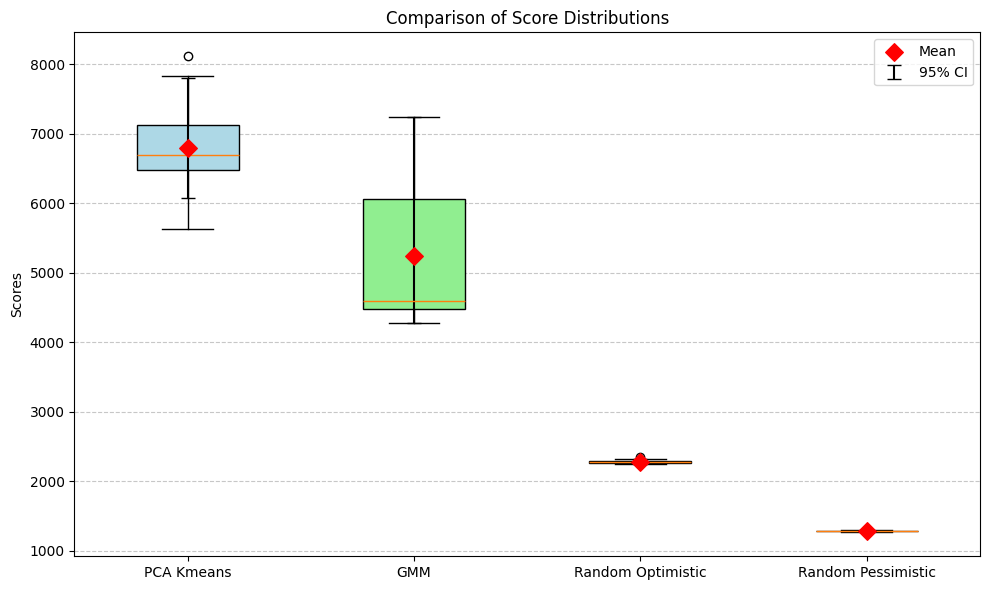

In [190]:
means = [np.mean(scores), np.mean(scores_vmog), np.mean(scores_optimistic), np.mean(scores_pessimistic)]

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplots
data = [scores, scores_vmog, scores_optimistic, scores_pessimistic]
box = ax.boxplot(data, patch_artist=True, positions=[1, 2, 3, 4])

# Customize boxplot colors
colors = ['lightblue', 'lightgreen', 'lightsalmon', 'lavender']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Add means as diamond markers
ax.scatter([1, 2, 3, 4], means, marker='D', color='red', s=80, zorder=3, label='Mean')

# Add credible intervals as error bars
ax.errorbar([1, 2, 3, 4], means, yerr=[
                [means[0] - lower, means[1] - lower_vmog, means[2] - lower_optimistic, means[3] - lower_pessimistic],
                [-means[0] + upper, -means[1] + upper_vmog, -means[2] + upper_optimistic, -means[3] + upper_pessimistic]
            ], fmt='none', color='black', capsize=5, label='95% CI')

# Add labels and title
ax.set_ylabel('Scores')
ax.set_title('Comparison of Score Distributions')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['PCA Kmeans', 'GMM', 'Random Optimistic', 'Random Pessimistic'])

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add legend
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [191]:
my_list = [95000] * 48

In [192]:
gt = np.array(my_list)
gt

array([95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000, 95000,
       95000, 95000, 95000])

In [193]:
np.mean(scores_pessimistic)

np.float64(1281.5625)

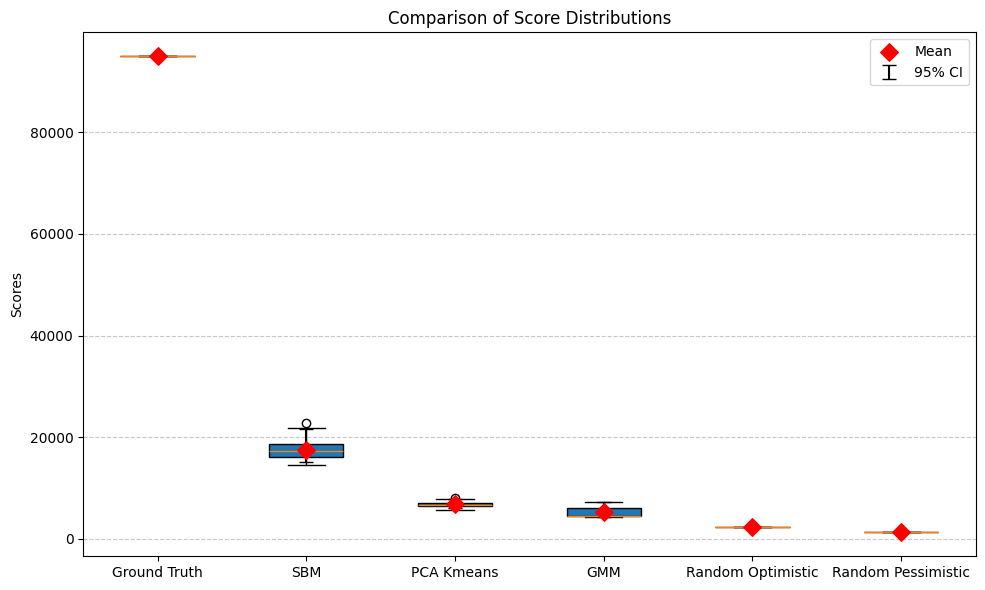

In [194]:
means = [95000, np.mean(scores_sbm), np.mean(scores), np.mean(scores_vmog), np.mean(scores_optimistic), np.mean(scores_pessimistic)]

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplots
data = [gt, scores_sbm, scores, scores_vmog, scores_optimistic, scores_pessimistic]
box = ax.boxplot(data, patch_artist=True, positions=[1, 2, 3, 4, 5, 6])

# Customize boxplot colors
# colors = ['red', 'lightblue', 'lightgreen', 'lightsalmon', 'lavender']
# for patch, color in zip(box['boxes'], colors):
#     patch.set_facecolor(color)

# Add means as diamond markers
ax.scatter([1, 2, 3, 4, 5, 6], means, marker='D', color='red', s=80, zorder=3, label='Mean')

# Add credible intervals as error bars
ax.errorbar([1, 2, 3, 4, 5, 6], means, yerr=[
                [0, means[1] - lower_sbm, means[2] - lower, means[3] - lower_vmog, means[4] - lower_optimistic, means[5] - lower_pessimistic],
                [0, -means[1] + upper_sbm, -means[2] + upper, -means[3] + upper_vmog, -means[4] + upper_optimistic, -means[5] + upper_pessimistic]
            ], fmt='none', color='black', capsize=5, label='95% CI')

# Add labels and title
ax.set_ylabel('Scores')
ax.set_title('Comparison of Score Distributions')
ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xticklabels(['Ground Truth', 'SBM', 'PCA Kmeans', 'GMM', 'Random Optimistic', 'Random Pessimistic'])

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add legend
ax.legend()

# Show the plot

plt.tight_layout()

plt.show()


C:\Users\ROG\AppData\Local\Temp\ipykernel_29776\2484864054.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


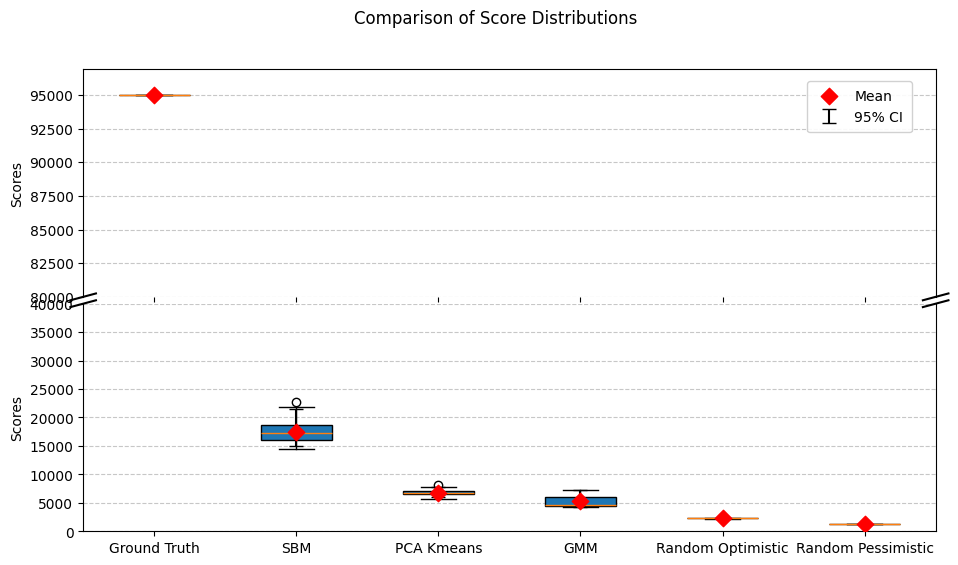

In [195]:
import numpy as np
import matplotlib.pyplot as plt

means = [95000, np.mean(scores_sbm), np.mean(scores), np.mean(scores_vmog),
         np.mean(scores_optimistic), np.mean(scores_pessimistic)]

positions = [1, 2, 3, 4, 5, 6]
labels = ['Ground Truth', 'SBM', 'PCA Kmeans', 'GMM', 'Random Optimistic', 'Random Pessimistic']
data = [gt, scores_sbm, scores, scores_vmog, scores_optimistic, scores_pessimistic]

ymax_candidates = []
for arr in data:
    if len(arr) > 0:
        ymax_candidates.append(np.nanmax(np.asarray(arr)))
ymax_candidates += [m for m in means if m is not None]
ymax_candidates += [upper_sbm, upper, upper_vmog, upper_optimistic, upper_pessimistic]
ymax = max(ymax_candidates) * 1.02  

fig, (ax_hi, ax_lo) = plt.subplots(
    2, 1, sharex=True, figsize=(11, 6),
    gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.03}
)

def draw_on(ax, add_legend=False):

    box = ax.boxplot(data, patch_artist=True, positions=positions)

    ax.scatter(positions, means, marker='D', color='red', s=70, zorder=3,
               label=('Mean' if add_legend else None))

    ax.errorbar(
        positions, means,
        yerr=[
            [0, means[1] - lower_sbm, means[2] - lower, means[3] - lower_vmog, means[4] - lower_optimistic, means[5] - lower_pessimistic],
            [0, -means[1] + upper_sbm, -means[2] + upper, -means[3] + upper_vmog, -means[4] + upper_optimistic, -means[5] + upper_pessimistic]
        ],
        fmt='none', color='black', capsize=5,
        label=('95% CI' if add_legend else None)
    )

    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

draw_on(ax_hi, add_legend=True)
draw_on(ax_lo, add_legend=False)

ax_lo.set_ylim(0, 40000)
ax_hi.set_ylim(80000, ymax)

for ax, which in [(ax_hi, 'bottom'), (ax_lo, 'top')]:
    ax.spines[which].set_visible(False)
ax_hi.tick_params(labeltop=False)  
ax_lo.xaxis.tick_bottom()

d = .015
kwargs_hi = dict(transform=ax_hi.transAxes, color='k', clip_on=False)
ax_hi.plot((-d, +d), (-d, +d), **kwargs_hi)
ax_hi.plot((1 - d, 1 + d), (-d, +d), **kwargs_hi)
kwargs_lo = dict(transform=ax_lo.transAxes, color='k', clip_on=False)
ax_lo.plot((-d, +d), (1 - d, 1 + d), **kwargs_lo)
ax_lo.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs_lo)


ax_lo.set_xticks(positions)
ax_lo.set_xticklabels(labels, rotation=0)
ax_lo.set_ylabel('Scores')
ax_hi.set_ylabel('Scores')

fig.suptitle('Comparison of Score Distributions (broken y-axis)')

fig.suptitle('Comparison of Score Distributions')


leg = ax_hi.legend(
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98),
    frameon=True,
    framealpha=0.9,
    borderpad=0.6,
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


In [196]:
# should we be expecting higher variance from GMM?

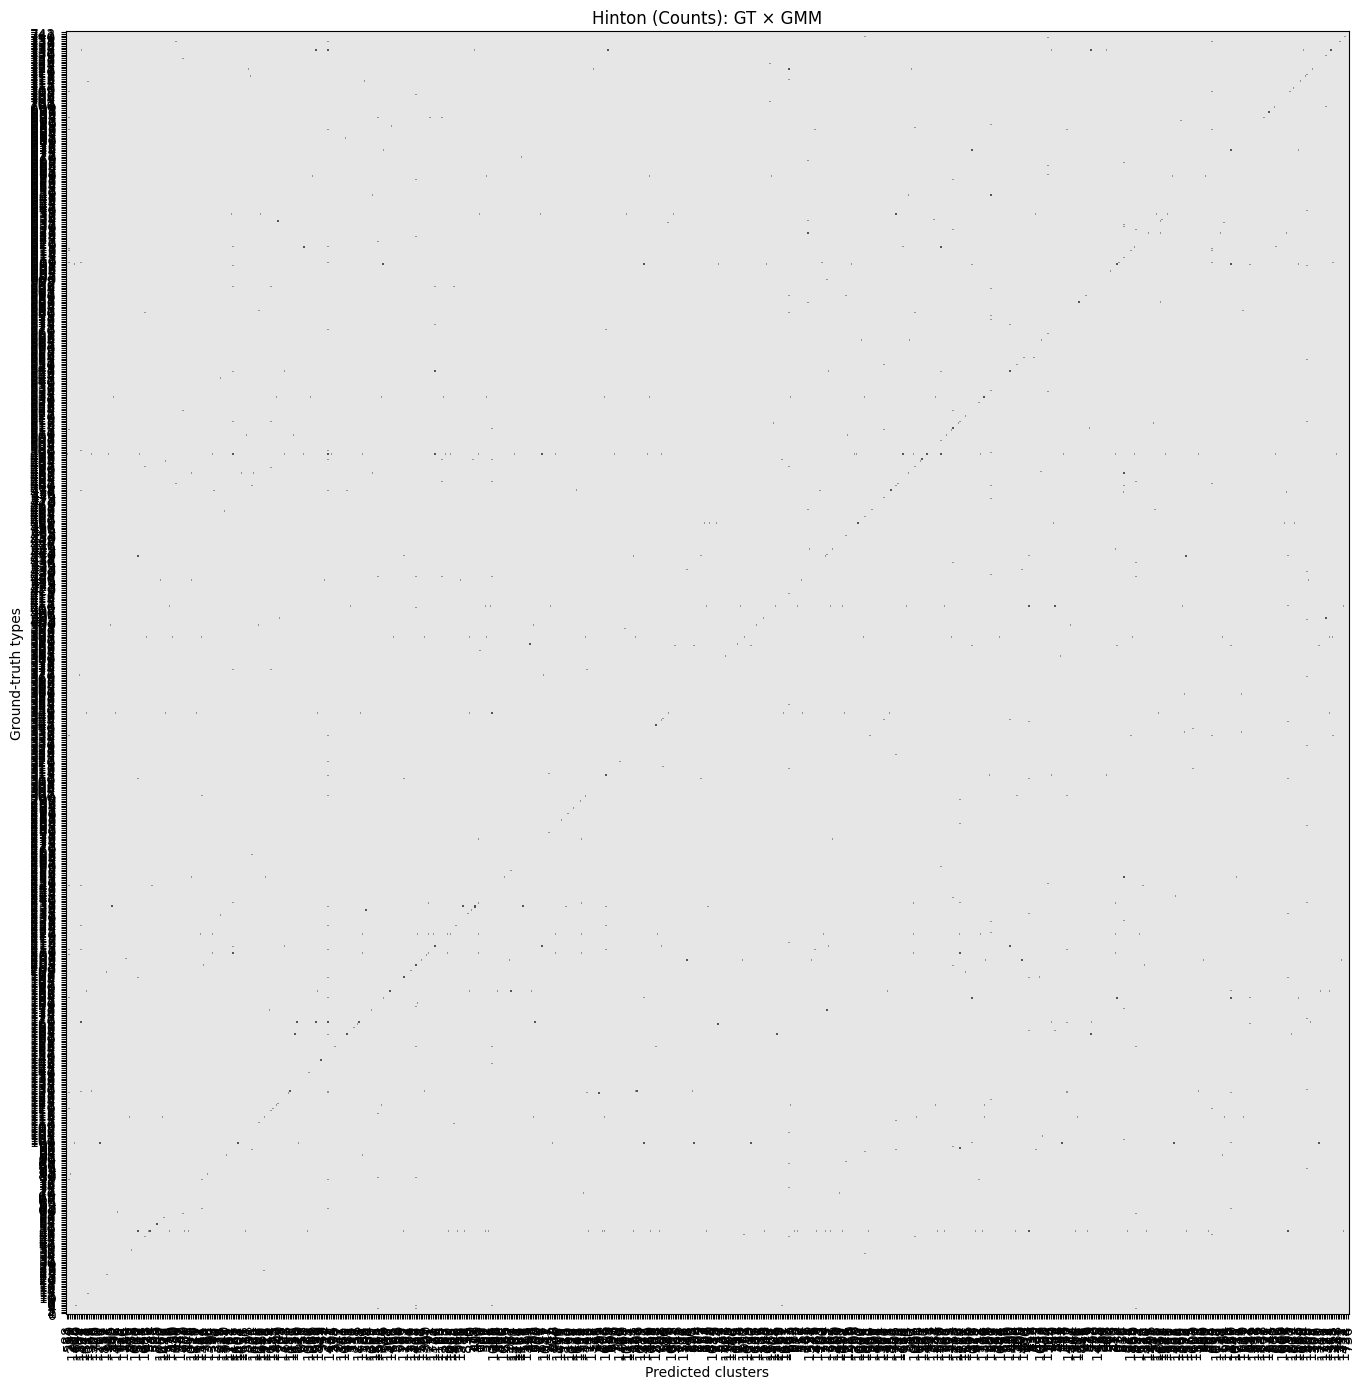

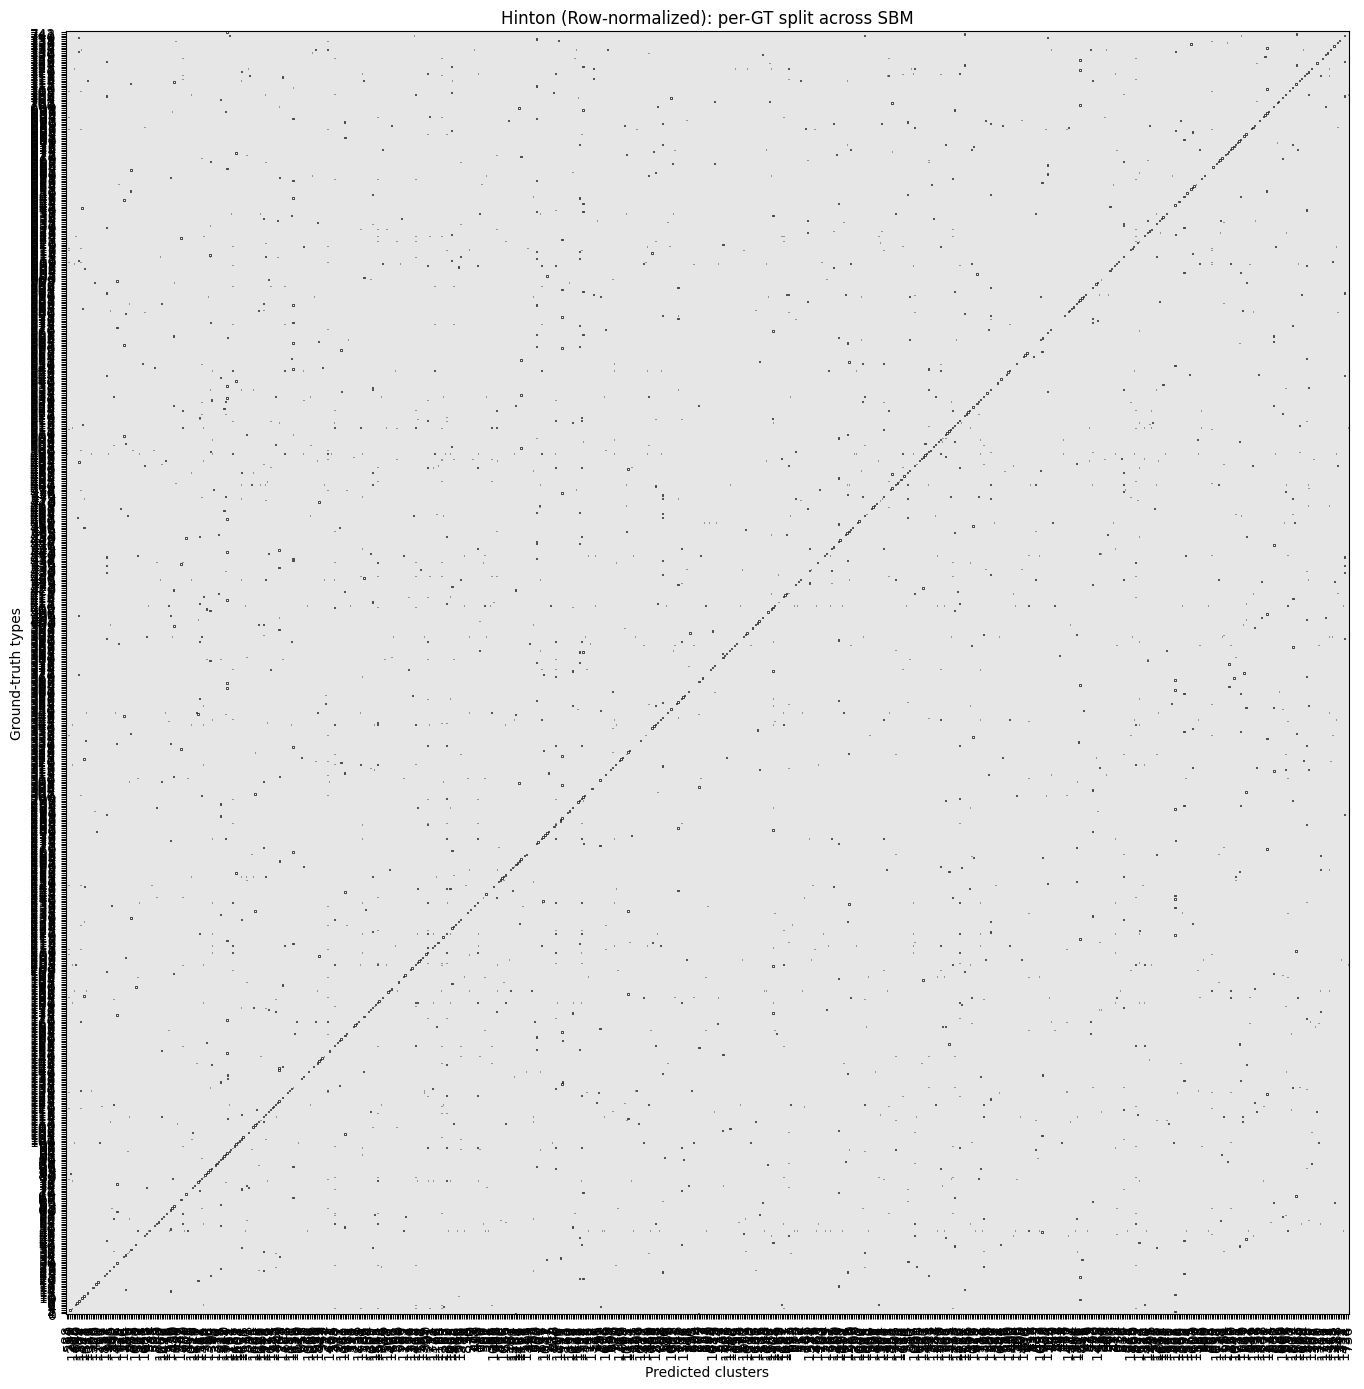

array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  2, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., 10,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(743, 743))

In [197]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.optimize import linear_sum_assignment

def make_consecutive_labels(y):
    y = np.asarray(y)
    uniq = np.unique(y)
    remap = {v: i for i, v in enumerate(uniq)}
    return np.array([remap[v] for v in y]), [str(v) for v in uniq]

def contingency_matrix(y_true, y_pred):
    C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
    np.add.at(C, (y_true, y_pred), 1)
    return C

def align_columns_by_hungarian(C):
    r, c = linear_sum_assignment(-C)
    return C[:, c], c

def hinton(ax, M, max_weight=None):
    ax.cla()
    h, w = M.shape
    if max_weight is None:
        max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
    ax.set_aspect('equal', 'box')
    ax.set_facecolor('0.9')
    ax.set_xlim(0, w); ax.set_ylim(0, h)
    for (i, j), v in np.ndenumerate(M):
        if v <= 0: continue
        s = np.sqrt(v / max_weight)
        rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
                             facecolor='white', edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)

def plot_hinton_gt_vs_pred(y_gt, y_pred, row_names=None, col_names=None,
                           normalize='none', align=True, title='Hinton'):
    C = contingency_matrix(y_gt, y_pred)
    if align:
        C, col_perm = align_columns_by_hungarian(C)
        if col_names is not None:
            col_names = [col_names[j] for j in col_perm]
    C_plot = C.astype(float)
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs==0]=1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs==0]=1
        C_plot = C_plot / cs

    # fig, ax = plt.subplots(figsize=(min(18, 2+0.5*C.shape[1]), min(14, 2+0.5*C.shape[0])))
    fig, ax = plt.subplots(
    figsize=(min(18, 2+0.5*C.shape[1]),  # width ∝ #cols
             min(14, 2+0.5*C.shape[0]))  # height ∝ #rows
)

    hinton(ax, C_plot)
    ax.set_title(title); ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')
    ax.set_xticks(np.arange(C.shape[1]) + 0.5)
    ax.set_yticks(np.arange(C.shape[0]) + 0.5)
    ax.set_xticklabels(col_names if col_names is not None else [f'c{j}' for j in range(C.shape[1])], rotation=90)
    ax.set_yticklabels(row_names if row_names is not None else [f't{i}' for i in range(C.shape[0])])
    plt.tight_layout(); plt.show()
    return C

#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(sbm_assignments)

#4 draw count-based hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='none', align=True,
    title='Hinton (Counts): GT × GMM'
)

#5 draw row-normalized hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized): per-GT split across SBM'
)

In [198]:
print("Number of ground-truth types:", len(np.unique(y_gt_i)))
print("Number of predicted clusters:", len(np.unique(y_ro_i)))

Number of ground-truth types: 743
Number of predicted clusters: 1191


In [199]:
with open("root_id_to_index_mapping.json", "r") as f:
    rid2idx = json.load(f)                     
idx2rid = {int(v): int(k) for k, v in rid2idx.items()}

lv_dict_idx = np.load('vmog_runs/vmog_cluster_assignment_dict_tuned_2.npy', allow_pickle=True).item()

lv_cluster_assignment_dict = { idx2rid[int(idx)]: int(lbl)
                 for idx, lbl in lv_dict_idx.items()
                 if int(idx) in idx2rid }

shared_root_ids = list(set(root_id_type_dict.keys())
                       .intersection(set(pca_cluster_assignment_dict.keys()))
                                     .intersection(set(lv_cluster_assignment_dict.keys()))
                                        .intersection(set(sbm_cluster_assignment_dict.keys())))


lv_assignments = np.array([lv_cluster_assignment_dict[root_id] for root_id in shared_root_ids])
y_KM_i, names = make_consecutive_labels(lv_assignments)
print("Number of predicted clusters:", len(np.unique(y_KM_i)))

Number of predicted clusters: 542


In [200]:
unique_labels = np.unique(lv_assignments)
print("Unique cluster IDs:", unique_labels[:20], "...")
print("Total clusters present:", len(unique_labels))

Unique cluster IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] ...
Total clusters present: 542


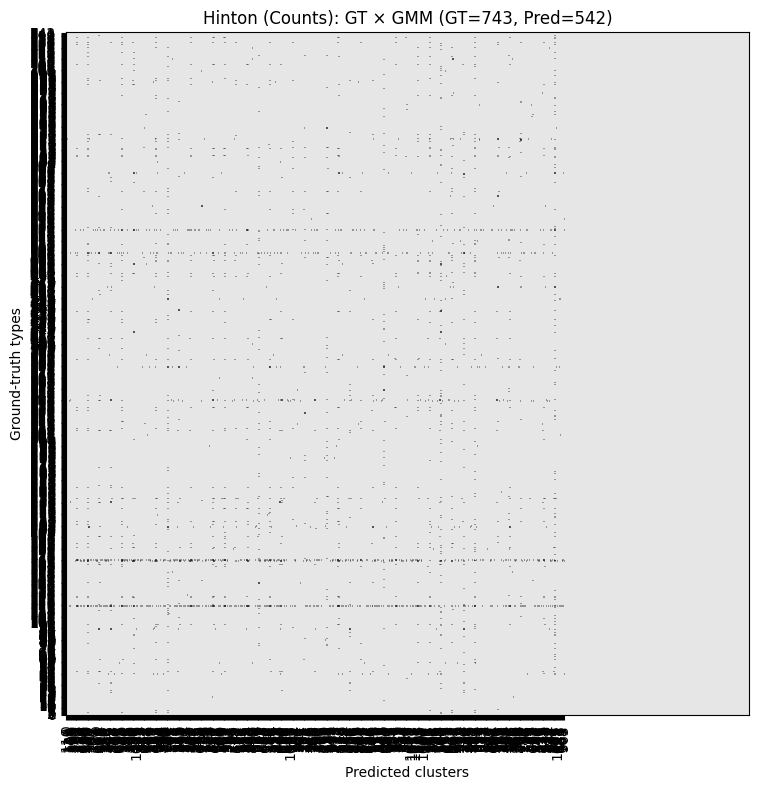

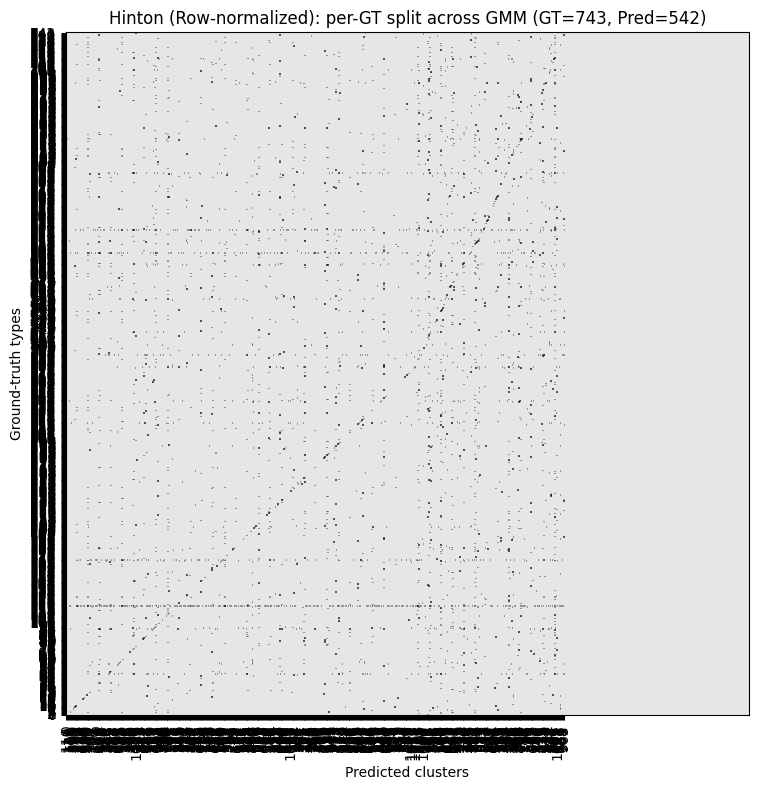

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 9],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(743, 542))

In [201]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.optimize import linear_sum_assignment

def make_consecutive_labels(y):
    y = np.asarray(y)
    uniq = np.unique(y)
    remap = {v: i for i, v in enumerate(uniq)}
    return np.array([remap[v] for v in y]), [str(v) for v in uniq]

def contingency_matrix(y_true, y_pred):
    C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
    np.add.at(C, (y_true, y_pred), 1)
    return C

def align_columns_by_hungarian(C):
    r, c = linear_sum_assignment(-C)
    return C[:, c], c

def hinton(ax, M, max_weight=None):
    ax.cla()
    h, w = M.shape
    if max_weight is None:
        max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
    ax.set_aspect('equal', 'box')
    ax.set_facecolor('0.9')
    ax.set_xlim(0, w); ax.set_ylim(0, h)
    for (i, j), v in np.ndenumerate(M):
        if v <= 0: continue
        s = np.sqrt(v / max_weight)
        rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
                             facecolor='white', edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)
def plot_hinton_gt_vs_pred(y_gt, y_pred, row_names=None, col_names=None,
                           normalize='none', align=True, title='Hinton',
                           pad_to_square=True):
    C = contingency_matrix(y_gt, y_pred)
    if align:
        C, col_perm = align_columns_by_hungarian(C)
        if col_names is not None:
            col_names = [col_names[j] for j in col_perm]
    C_plot = C.astype(float)
    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs==0] = 1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs==0] = 1
        C_plot = C_plot / cs

    # --- pad to square ---
    if pad_to_square:
        n = max(C_plot.shape)
        S = np.zeros((n, n), dtype=C_plot.dtype)
        S[:C_plot.shape[0], :C_plot.shape[1]] = C_plot
    else:
        S = C_plot

    # --- make figure square ---
    fig, ax = plt.subplots(figsize=(8, 8))
    hinton(ax, S)
    ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[1]})")
    ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

    ax.set_xticks(np.arange(C.shape[1]) + 0.5)
    ax.set_yticks(np.arange(C.shape[0]) + 0.5)
    ax.set_xticklabels(
        col_names if col_names is not None else [f'c{j}' for j in range(C.shape[1])],
        rotation=90
    )
    ax.set_yticklabels(
        row_names if row_names is not None else [f't{i}' for i in range(C.shape[0])]
    )
    ax.set_xlim(0, S.shape[1]); ax.set_ylim(0, S.shape[0])

    plt.tight_layout()
    plt.show()
    return C


#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(lv_assignments)

#4 draw count-based hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='none', align=True,
    title='Hinton (Counts): GT × GMM'
)

#5 draw row-normalized hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized): per-GT split across GMM'
)

In [202]:
a = 2695/371
a

7.264150943396227

In [203]:
y = [21, 59, 25, 127]
x = [4, 9, 7, 15]
t = 0
for i in range(len(y)):
    t += (y[i] - x[i]*a)**2

t/4

274.7783018867925

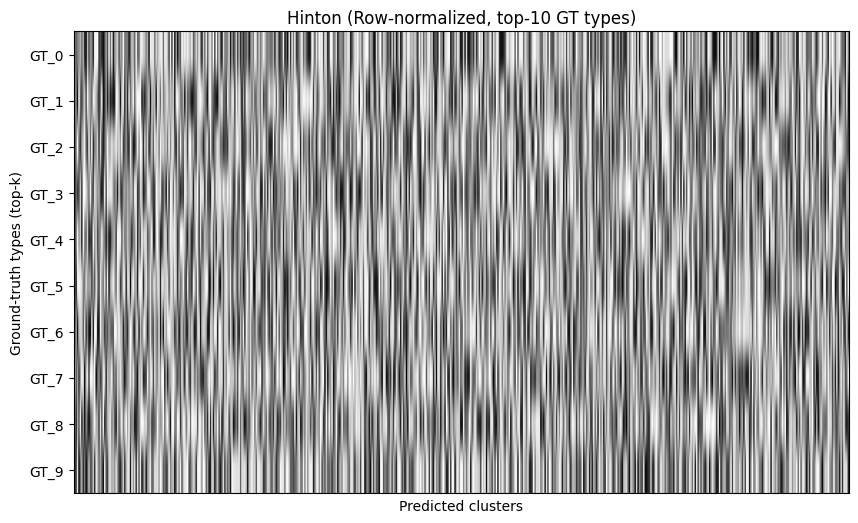

In [204]:
import matplotlib.pyplot as plt
import numpy as np

# Let's simulate a similar Hinton diagram with fewer labels (top-k GT types)
# Since we don't have the actual plotting code yet, I'll create a function that
# trims the matrix to top-k rows for visualization.

def plot_hinton_topk(matrix, gt_labels, pred_labels, top_k=10):
    """
    Plot a simplified Hinton diagram with only the top_k ground-truth rows.
    
    Args:
        matrix (np.ndarray): Row-normalized GT x Pred matrix.
        gt_labels (list): Ground-truth type labels.
        pred_labels (list): Predicted cluster labels.
        top_k (int): Number of top GT types to show.
    """
    # Select top_k rows (e.g., first top_k)
    matrix_topk = matrix[:top_k, :]
    gt_labels_topk = gt_labels[:top_k]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(matrix_topk, cmap="Greys", aspect="auto")
    
    # Set ticks
    ax.set_yticks(np.arange(top_k))
    ax.set_yticklabels(gt_labels_topk)
    ax.set_xticks([])  # avoid cluttered x-axis
    ax.set_xlabel("Predicted clusters")
    ax.set_ylabel("Ground-truth types (top-k)")
    ax.set_title(f"Hinton (Row-normalized, top-{top_k} GT types)")
    
    plt.show()

# Example: simulate a 743x542 matrix and visualize top-10 rows
np.random.seed(0)
matrix = np.random.rand(743, 542)
matrix = matrix / matrix.sum(axis=1, keepdims=True)  # row normalize
gt_labels = [f"GT_{i}" for i in range(743)]
pred_labels = [f"Pred_{j}" for j in range(542)]

plot_hinton_topk(matrix, gt_labels, pred_labels, top_k=10)


In [205]:
def plot_hinton_gt_vs_pred(
    y_gt, y_pred, row_names=None, col_names=None,
    normalize='none', align=True, title='Hinton',
    pad_to_square=True,
    top_k_rows=None, top_k_cols=None, top_by='count', keep_rest_as_other=True
):

    C = contingency_matrix(y_gt, y_pred)
    if align:
        try:
            from scipy.optimize import linear_sum_assignment
            C, col_perm = align_columns_by_hungarian(C)
            if col_names is not None:
                col_names = [col_names[j] for j in col_perm]
        except Exception:
            pass

    if row_names is None:
        row_names = [f't{i}' for i in range(C.shape[0])]
    if col_names is None:
        col_names = [f'c{j}' for j in range(C.shape[1])]

    C_plot = C.astype(float)

    if normalize == 'row':
        rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
        C_plot = C_plot / rs
    elif normalize == 'col':
        cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
        C_plot = C_plot / cs

    if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
        if top_by == 'count':
            row_score = C.sum(axis=1)
        else:  # 'mass'
            row_score = C_plot.sum(axis=1)
        top_idx = np.argsort(row_score)[::-1][:top_k_rows]
        rest_idx = np.setdiff1d(np.arange(C_plot.shape[0]), top_idx)

        C_rows = C_plot[top_idx, :]
        names_rows = [row_names[i] for i in top_idx]

        if keep_rest_as_other and rest_idx.size > 0:
            other_row = C_plot[rest_idx, :].sum(axis=0, keepdims=True)
            C_rows = np.vstack([C_rows, other_row])
            names_rows.append('Other')

        C_plot = C_rows
        row_names = names_rows

    # --- Top-K ---
    if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
        if top_by == 'count':
            col_score = C.sum(axis=0)
        else:  # 'mass'
            col_score = C_plot.sum(axis=0)
        top_j = np.argsort(col_score)[::-1][:top_k_cols]
        rest_j = np.setdiff1d(np.arange(C_plot.shape[1]), top_j)

        C_cols = C_plot[:, top_j]
        names_cols = [col_names[j] for j in top_j]

        if keep_rest_as_other and rest_j.size > 0:
            other_col = C_plot[:, rest_j].sum(axis=1, keepdims=True)
            C_cols = np.hstack([C_cols, other_col])
            names_cols.append('Other')

        C_plot = C_cols
        col_names = names_cols

    # --- pad to square ---
    if pad_to_square:
        n = max(C_plot.shape)
        S = np.zeros((n, n), dtype=C_plot.dtype)
        S[:C_plot.shape[0], :C_plot.shape[1]] = C_plot
    else:
        S = C_plot

    fig, ax = plt.subplots(figsize=(8, 8))
    hinton(ax, S)
    ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[0]})")
    ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

    ax.set_xticks(np.arange(C_plot.shape[1]) + 0.5)
    ax.set_yticks(np.arange(C_plot.shape[0]) + 0.5)
    ax.set_xticklabels(col_names, rotation=90)
    ax.set_yticklabels(row_names)

    ax.set_xlim(0, S.shape[1]); ax.set_ylim(0, S.shape[0])
    plt.tight_layout()
    plt.show()
    return C


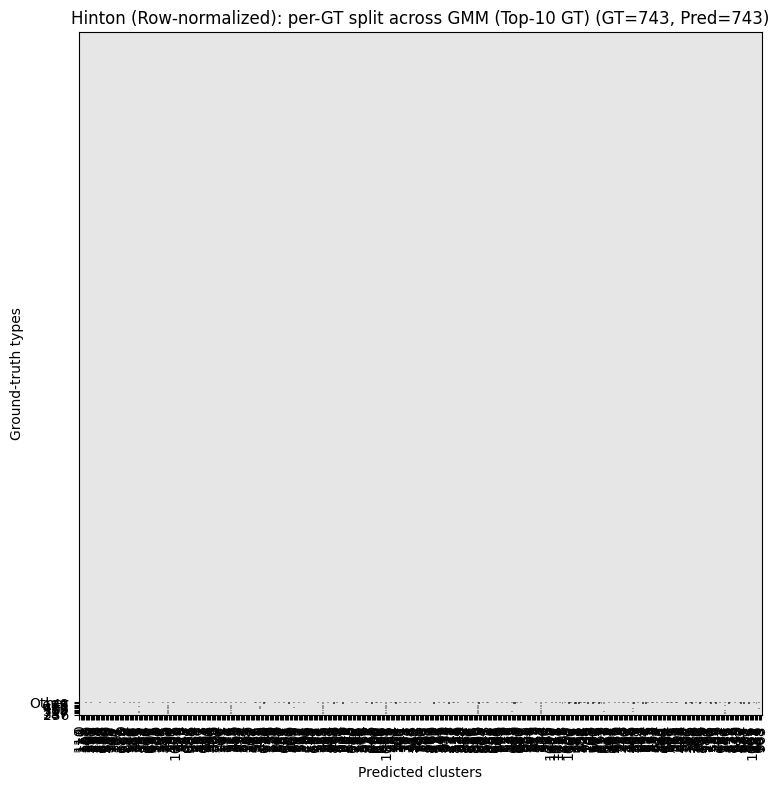

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 9],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(743, 542))

In [206]:

#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(lv_assignments)

#4 draw count-based hinton
plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=gt_names, col_names=ro_names,
    normalize='row', align=True,
    title='Hinton (Row-normalized): per-GT split across GMM (Top-10 GT)',
    top_k_rows=10, top_k_cols=None, top_by='count', keep_rest_as_other=True
)


In [207]:
# def plot_hinton_gt_vs_pred(
#     y_gt, y_pred, row_names=None, col_names=None,
#     normalize='none', align=True, title='Hinton',
#     pad_to_square=False,               # 关键：默认改为 False
#     top_k_rows=None, top_k_cols=None,  # 仅裁剪，不合并“Other”
#     top_by='count'                     # 'count' or 'mass'
# ):
#     C = contingency_matrix(y_gt, y_pred)

#     if align:
#         try:
#             from scipy.optimize import linear_sum_assignment
#             C, col_perm = align_columns_by_hungarian(C)
#             if col_names is not None:
#                 col_names = [col_names[j] for j in col_perm]
#         except Exception:
#             pass

#     if row_names is None:
#         row_names = [f't{i}' for i in range(C.shape[0])]
#     if col_names is None:
#         col_names = [f'c{j}' for j in range(C.shape[1])]

#     C_plot = C.astype(float)

#     # 归一化（若需要）
#     if normalize == 'row':
#         rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
#         C_plot = C_plot / rs
#     elif normalize == 'col':
#         cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
#         C_plot = C_plot / cs

#     # ---- 仅裁剪 Top-K 行（不合并“Other”）----
#     if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
#         if top_by == 'count':
#             row_score = C.sum(axis=1)
#         else:  # 'mass'
#             row_score = C_plot.sum(axis=1)
#         top_i = np.argsort(row_score)[::-1][:top_k_rows]
#         C_plot = C_plot[top_i, :]
#         row_names = [row_names[i] for i in top_i]

#     # ---- 仅裁剪 Top-K 列（不合并“Other”）----
#     if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
#         if top_by == 'count':
#             col_score = C.sum(axis=0)
#         else:
#             col_score = C_plot.sum(axis=0)
#         top_j = np.argsort(col_score)[::-1][:top_k_cols]
#         C_plot = C_plot[:, top_j]
#         col_names = [col_names[j] for j in top_j]

#     # ---- 不再 pad 成方阵（避免大片灰色留白）----
#     S = C_plot
#     H, W = S.shape

#     # 根据内容自适应画布宽高：行少时更扁、列多时更宽
#     # 你也可以直接写成固定值，比如 figsize=(8, 5)
#     fig_w = max(6, min(16, 0.03 * W + 6))
#     fig_h = max(3, min(10, 0.5 * (H / 10) + 3))
#     fig, ax = plt.subplots(figsize=(fig_w, fig_h))

#     hinton(ax, S)  # 用当前尺寸的矩阵作图
#     ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[0]})")
#     ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

#     # 只为当前子矩阵设置刻度与标签
#     ax.set_xlim(0, W); ax.set_ylim(0, H)
#     ax.set_xticks(np.arange(W) + 0.5)
#     ax.set_yticks(np.arange(H) + 0.5)

#     # X 轴标签太多会重叠：做一个稀疏显示（每隔 n 个显示一个）
#     if W > 60:
#         step = int(np.ceil(W / 60))  # 保持最多 ~60 个标签
#         xticklabels = [lbl if i % step == 0 else '' for i, lbl in enumerate(col_names)]
#     else:
#         xticklabels = col_names
#     ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
#     ax.set_yticklabels(row_names, fontsize=9)

#     plt.tight_layout()
#     plt.show()
#     return C


In [208]:
# def plot_hinton_gt_vs_pred(
#     y_gt, y_pred, row_names=None, col_names=None,
#     normalize='none', align=True, title='Hinton',
#     pad_to_square=False,
#     top_k_rows=None, top_k_cols=None,
#     top_by='count',                 # 兼容：若下面两个未设置，行列都用它
#     top_by_rows=None, top_by_cols=None
# ):
#     """
#     Hinton diagram with radix-style sorting (rows & cols), then Top-K selection.

#     - Radix排序键（稳定排序，先次键后主键）:
#         主键: 'strength' = 行/列强度 (count 或 mass)
#         次键: 行/列最大峰值 peak (降序)
#         第三键: 熵 entropy (升序，越小越集中)
#     - 排序完成后再按 top_k_rows / top_k_cols 截取
#     """
#     # -------------------- helpers --------------------
#     def contingency_matrix(y_true, y_pred):
#         C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
#         np.add.at(C, (y_true, y_pred), 1)
#         return C

#     def align_columns_by_hungarian(C):
#         # 对 counts 做对齐；后续我们仍会再做排序
#         from scipy.optimize import linear_sum_assignment
#         r, c = linear_sum_assignment(-C)
#         return C[:, c], c

#     def hinton(ax, M, max_weight=None):
#         ax.cla()
#         h, w = M.shape
#         if max_weight is None:
#             max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
#         ax.set_aspect('equal', 'box')
#         ax.set_facecolor('0.9')
#         ax.set_xlim(0, w); ax.set_ylim(0, h)
#         for (i, j), v in np.ndenumerate(M):
#             if v <= 0: 
#                 continue
#             s = np.sqrt(v / max_weight)
#             rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
#                                  facecolor='white', edgecolor='black', linewidth=0.5)
#             ax.add_patch(rect)

#     # -------------------- base matrices --------------------
#     C = contingency_matrix(y_gt, y_pred)

#     if align:
#         try:
#             C, col_perm = align_columns_by_hungarian(C)
#             if col_names is not None:
#                 col_names = [col_names[j] for j in col_perm]
#         except Exception:
#             pass

#     if row_names is None:
#         row_names = [f't{i}' for i in range(C.shape[0])]
#     if col_names is None:
#         col_names = [f'c{j}' for j in range(C.shape[1])]

#     C_plot = C.astype(float)

#     # -------- normalization (affects mass/peak/entropy) --------
#     if normalize == 'row':
#         rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
#         C_plot = C_plot / rs
#     elif normalize == 'col':
#         cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
#         C_plot = C_plot / cs

#     # 默认行列的 top_by
#     if top_by_rows is None: top_by_rows = top_by
#     if top_by_cols is None: top_by_cols = top_by

#     # -------------------- RADIX SORT: ROWS --------------------
#     # 度量
#     row_count   = C.sum(axis=1).astype(float)   # 行样本数（未归一化）
#     row_mass    = C_plot.sum(axis=1)            # 行“质量”（受归一化影响）
#     row_peak    = C_plot.max(axis=1)            # 行最大峰值
#     eps = 1e-12
#     row_entropy = -(C_plot * np.log(C_plot + eps)).sum(axis=1)  # 越小越集中

#     primary_row_strength = row_count if top_by_rows == 'count' else row_mass

#     # 稳定排序：先第三键(熵↑)、再第二键(峰↓)、最后主键(强度↓)
#     order_rows = np.arange(C_plot.shape[0])
#     order_rows = order_rows[np.argsort(row_entropy[order_rows], kind='stable')]          # ↑
#     order_rows = order_rows[np.argsort(-row_peak[order_rows], kind='stable')]            # ↓
#     order_rows = order_rows[np.argsort(-primary_row_strength[order_rows], kind='stable')]# ↓

#     C_plot   = C_plot[order_rows, :]
#     row_names = [row_names[i] for i in order_rows]
#     # 注意：这里暂不截取 top_k_rows，先把列也排序完（列的统计尽量用完整行）

#     # -------------------- RADIX SORT: COLS --------------------
#     # 使用当前 C_plot（行已重排但未截取），对列做度量
#     col_count   = C.sum(axis=0).astype(float)
#     col_mass    = C_plot.sum(axis=0)
#     col_peak    = C_plot.max(axis=0)
#     # 列的“熵”：看列向各行的分布
#     col_probs = C_plot / (C_plot.sum(axis=0, keepdims=True) + eps)
#     col_entropy = -(col_probs * np.log(col_probs + eps)).sum(axis=0)

#     primary_col_strength = col_count if top_by_cols == 'count' else col_mass

#     order_cols = np.arange(C_plot.shape[1])
#     order_cols = order_cols[np.argsort(col_entropy[order_cols], kind='stable')]          # ↑
#     order_cols = order_cols[np.argsort(-col_peak[order_cols], kind='stable')]            # ↓
#     order_cols = order_cols[np.argsort(-primary_col_strength[order_cols], kind='stable')]# ↓

#     C_plot    = C_plot[:, order_cols]
#     col_names  = [col_names[j] for j in order_cols]

#     # -------------------- select Top-K after sorting --------------------
#     if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
#         C_plot    = C_plot[:top_k_rows, :]
#         row_names = row_names[:top_k_rows]

#     if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
#         C_plot    = C_plot[:, :top_k_cols]
#         col_names = col_names[:top_k_cols]

#     # -------------------- plot --------------------
#     S = C_plot
#     H, W = S.shape

#     # 自适应画布
#     fig_w = max(6, min(16, 0.03 * W + 6))
#     fig_h = max(3, min(10, 0.5 * (H / 10) + 3))
#     fig, ax = plt.subplots(figsize=(fig_w, fig_h))

#     hinton(ax, S)
#     ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[1]})")  # 修正 Pred 计数
#     ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')

#     ax.set_xlim(0, W); ax.set_ylim(0, H)
#     ax.set_xticks(np.arange(W) + 0.5)
#     ax.set_yticks(np.arange(H) + 0.5)

#     # 稀疏 x 轴标签
#     if W > 60:
#         step = int(np.ceil(W / 60))
#         xticklabels = [col_names[i] if i % step == 0 else '' for i in range(W)]
#     else:
#         xticklabels = col_names
#     ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
#     ax.set_yticklabels(row_names, fontsize=9)

#     plt.tight_layout()
#     plt.show()
#     return C


In [209]:
# def plot_hinton_gt_vs_pred(
#     y_gt, y_pred, row_names=None, col_names=None,
#     normalize='none', align=True, title='Hinton',
#     pad_to_square=False,
#     top_k_rows=None, top_k_cols=None,
#     top_by='count',
#     corner='tr'               # 'tl'|'tr'|'bl'|'br'  把大配对块放到哪个角
# ):
#     # ---- helpers ----
#     def contingency_matrix(y_true, y_pred):
#         C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
#         np.add.at(C, (y_true, y_pred), 1)
#         return C

#     def align_columns_by_hungarian(C):
#         try:
#             from scipy.optimize import linear_sum_assignment
#             r, c = linear_sum_assignment(-C)
#             return C[:, c], c
#         except Exception:
#             return C, np.arange(C.shape[1])

#     def hinton(ax, M, max_weight=None):
#         ax.cla()
#         h, w = M.shape
#         if max_weight is None:
#             max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
#         ax.set_aspect('equal', 'box'); ax.set_facecolor('0.9')
#         ax.set_xlim(0, w); ax.set_ylim(0, h)
#         for (i, j), v in np.ndenumerate(M):
#             if v <= 0: continue
#             s = np.sqrt(v / max_weight)
#             rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
#                                  facecolor='white', edgecolor='black', linewidth=0.5)
#             ax.add_patch(rect)

#     # ---- base ----
#     C = contingency_matrix(y_gt, y_pred)
#     if align:
#         C, col_perm = align_columns_by_hungarian(C)
#         if col_names is not None:
#             col_names = [col_names[j] for j in col_perm]

#     if row_names is None: row_names = [f't{i}' for i in range(C.shape[0])]
#     if col_names is None: col_names = [f'c{j}' for j in range(C.shape[1])]

#     C_plot = C.astype(float)

#     # ---- normalize (affects overlaps we sort by) ----
#     if normalize == 'row':
#         rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
#         C_plot = C_plot / rs
#     elif normalize == 'col':
#         cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
#         C_plot = C_plot / cs

#     # ---- sort rows by "how well they are clustered" (peak desc, then count/mass desc) ----
#     peak_val = C_plot.max(axis=1)
#     peak_col = C_plot.argmax(axis=1)
#     strength = (C.sum(axis=1).astype(float) if top_by=='count' else C_plot.sum(axis=1))

#     # 行排序：先按峰值，再按强度（都降序），最后稳定按峰列分组
#     order_rows = np.arange(C_plot.shape[0])
#     order_rows = order_rows[np.argsort(peak_col[order_rows], kind='stable')]      # 分组
#     order_rows = order_rows[np.argsort(-strength[order_rows], kind='stable')]     # 强度↓
#     order_rows = order_rows[np.argsort(-peak_val[order_rows], kind='stable')]     # 峰值↓

#     C_plot  = C_plot[order_rows, :]
#     row_names = [row_names[i] for i in order_rows]
#     peak_col  = peak_col[order_rows]

#     # ---- derive a column order so that row i's best column appears early ----
#     # 取行的主峰列的“首次出现顺序”作为列的优先级，剩余列按列强度降序
#     seen = set(); primary_cols = []
#     for j in peak_col:
#         if j not in seen:
#             seen.add(int(j)); primary_cols.append(int(j))
#     # 剩余列按列强度（或质量）降序
#     remaining = [j for j in range(C_plot.shape[1]) if j not in seen]
#     col_strength = (C.sum(axis=0).astype(float) if top_by=='count' else C_plot.sum(axis=0))
#     remaining.sort(key=lambda j: -col_strength[j])
#     order_cols = primary_cols + remaining

#     C_plot   = C_plot[:, order_cols]
#     col_names = [col_names[j] for j in order_cols]

#     # ---- place big blocks into desired corner ----
#     # 右上角需要：行从上到下是强→弱（已满足），列从右到左是主→次 → 反转列
#     if corner in ('tr', 'br'):
#         C_plot   = C_plot[:, ::-1]
#         col_names = col_names[::-1]
#     if corner in ('bl', 'br'):
#         C_plot   = C_plot[::-1, :]
#         row_names = row_names[::-1]

#     # ---- select Top-K after ordering ----
#     if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
#         C_plot   = C_plot[:top_k_rows, :]
#         row_names = row_names[:top_k_rows]
#     if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
#         C_plot   = C_plot[:, :top_k_cols]
#         col_names = col_names[:top_k_cols]

#     # ---- pad? (默认不 pad) ----
#     S = C_plot
#     H, W = S.shape

#     # ---- plot ----
#     fig_w = max(6, min(16, 0.03*W + 6))
#     fig_h = max(3, min(10, 0.5*(H/10) + 3))
#     fig, ax = plt.subplots(figsize=(fig_w, fig_h))
#     hinton(ax, S)

#     ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[1]})")
#     ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')
#     ax.set_xlim(0, W); ax.set_ylim(0, H)
#     ax.set_xticks(np.arange(W)+0.5); ax.set_yticks(np.arange(H)+0.5)

#     if W > 60:
#         step = int(np.ceil(W/60))
#         xticklabels = [col_names[i] if i % step == 0 else '' for i in range(W)]
#     else:
#         xticklabels = col_names
#     ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
#     ax.set_yticklabels(row_names, fontsize=9)

#     plt.tight_layout()
#     plt.show()
#     return C


In [210]:
# def plot_hinton_gt_vs_pred(
#     y_gt, y_pred, row_names=None, col_names=None,
#     normalize='none', align=True, title='Hinton',
#     pad_to_square=False,
#     top_k_rows=None, top_k_cols=None,
#     top_by='count',
#     corner='tr'               # 'tl'|'tr'|'bl'|'br'  把大配对块放到哪个角
#     save_csv_path=None
# ):
#     # ---- helpers ----
#     def contingency_matrix(y_true, y_pred):
#         C = np.zeros((int(y_true.max())+1, int(y_pred.max())+1), dtype=np.int64)
#         np.add.at(C, (y_true, y_pred), 1)
#         return C

#     def align_columns_by_hungarian(C):
#         try:
#             from scipy.optimize import linear_sum_assignment
#             r, c = linear_sum_assignment(-C)
#             return C[:, c], c
#         except Exception:
#             return C, np.arange(C.shape[1])

#     def hinton(ax, M, max_weight=None):
#         ax.cla()
#         h, w = M.shape
#         if max_weight is None:
#             max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
#         ax.set_aspect('equal', 'box'); ax.set_facecolor('0.9')
#         ax.set_xlim(0, w); ax.set_ylim(0, h)
#         for (i, j), v in np.ndenumerate(M):
#             if v <= 0: continue
#             s = np.sqrt(v / max_weight)
#             rect = plt.Rectangle((j+0.5-s/2, i+0.5-s/2), s, s,
#                                  facecolor='white', edgecolor='black', linewidth=0.5)
#             ax.add_patch(rect)

#     # ---- base ----
#     C = contingency_matrix(y_gt, y_pred)
#     if align:
#         C, col_perm = align_columns_by_hungarian(C)
#         if col_names is not None:
#             col_names = [col_names[j] for j in col_perm]

#     if row_names is None: row_names = [f't{i}' for i in range(C.shape[0])]
#     if col_names is None: col_names = [f'c{j}' for j in range(C.shape[1])]

#     C_plot = C.astype(float)

#     # ---- normalize (affects overlaps we sort by) ----
#     if normalize == 'row':
#         rs = C_plot.sum(axis=1, keepdims=True); rs[rs == 0] = 1
#         C_plot = C_plot / rs
#     elif normalize == 'col':
#         cs = C_plot.sum(axis=0, keepdims=True); cs[cs == 0] = 1
#         C_plot = C_plot / cs

#     # ---- sort rows by "how well they are clustered" (peak desc, then count/mass desc) ----
#     peak_val = C_plot.max(axis=1)
#     peak_col = C_plot.argmax(axis=1)
#     strength = (C.sum(axis=1).astype(float) if top_by=='count' else C_plot.sum(axis=1))

#     # 行排序：先按峰值，再按强度（都降序），最后稳定按峰列分组
#     order_rows = np.arange(C_plot.shape[0])
#     order_rows = order_rows[np.argsort(peak_col[order_rows], kind='stable')]      # 分组
#     order_rows = order_rows[np.argsort(-strength[order_rows], kind='stable')]     # 强度↓
#     order_rows = order_rows[np.argsort(-peak_val[order_rows], kind='stable')]     # 峰值↓

#     C_plot  = C_plot[order_rows, :]
#     row_names = [row_names[i] for i in order_rows]
#     peak_col  = peak_col[order_rows]

#     # ---- derive a column order so that row i's best column appears early ----
#     # 取行的主峰列的“首次出现顺序”作为列的优先级，剩余列按列强度降序
#     seen = set(); primary_cols = []
#     for j in peak_col:
#         if j not in seen:
#             seen.add(int(j)); primary_cols.append(int(j))
#     # 剩余列按列强度（或质量）降序
#     remaining = [j for j in range(C_plot.shape[1]) if j not in seen]
#     col_strength = (C.sum(axis=0).astype(float) if top_by=='count' else C_plot.sum(axis=0))
#     remaining.sort(key=lambda j: -col_strength[j])
#     order_cols = primary_cols + remaining

#     C_plot   = C_plot[:, order_cols]
#     col_names = [col_names[j] for j in order_cols]

#     # ---- place big blocks into desired corner ----
#     # 右上角需要：行从上到下是强→弱（已满足），列从右到左是主→次 → 反转列
#     if corner in ('tr', 'br'):
#         C_plot   = C_plot[:, ::-1]
#         col_names = col_names[::-1]
#     if corner in ('bl', 'br'):
#         C_plot   = C_plot[::-1, :]
#         row_names = row_names[::-1]

#     # ---- select Top-K after ordering ----
#     if top_k_rows is not None and top_k_rows < C_plot.shape[0]:
#         C_plot   = C_plot[:top_k_rows, :]
#         row_names = row_names[:top_k_rows]
#     if top_k_cols is not None and top_k_cols < C_plot.shape[1]:
#         C_plot   = C_plot[:, :top_k_cols]
#         col_names = col_names[:top_k_cols]

#     # ---- pad? (默认不 pad) ----
#     S = C_plot
#     H, W = S.shape

#     # ---- plot ----
#     fig_w = max(6, min(16, 0.03*W + 6))
#     fig_h = max(3, min(10, 0.5*(H/10) + 3))
#     fig, ax = plt.subplots(figsize=(fig_w, fig_h))
#     hinton(ax, S)

#     ax.set_title(f"{title} (GT={C.shape[0]}, Pred={C.shape[1]})")
#     ax.set_xlabel('Predicted clusters'); ax.set_ylabel('Ground-truth types')
#     ax.set_xlim(0, W); ax.set_ylim(0, H)
#     ax.set_xticks(np.arange(W)+0.5); ax.set_yticks(np.arange(H)+0.5)

#     if W > 60:
#         step = int(np.ceil(W/60))
#         xticklabels = [col_names[i] if i % step == 0 else '' for i in range(W)]
#     else:
#         xticklabels = col_names
#     ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
#     ax.set_yticklabels(row_names, fontsize=9)

#     plt.tight_layout()
#     plt.show()


#     return C


In [264]:
def plot_hinton_gt_vs_pred(
    y_gt_i,
    y_ro_i,
    row_names=None,
    col_names=None,
    normalize='row',            # 'row' | 'col' | None
    score_metric='f1',          # 'f1' | 'precision' | 'recall' | 'count'
    top_k_pairs=70,
    corner='tr',                # 'tr' | 'tl' | 'br' | 'bl'
    title='Top best-fitted GT–Pred pairs',
    save_csv_path=None,
    eps=1e-12,
    filter_c=0,
    filter_f=0,
):
    """
    Hinton-style plot for GT (rows) vs Pred clusters (cols) based on a contingency table.
    Uses Hungarian / best-match on a score matrix and optionally saves top pairs to CSV.

    IMPORTANT FIX:
    - row_names_full / col_names_full always map ORIGINAL indices -> names.
    - row_names_plot / col_names_plot are ONLY for reordered/flipped display.
    - CSV uses *_full, never *_plot.
    """

    # -------------------------
    # 0) Build contingency matrix C (counts)
    # -------------------------
    y_gt_i = np.asarray(y_gt_i).astype(int)
    y_ro_i = np.asarray(y_ro_i).astype(int)

    n_gt = int(y_gt_i.max()) + 1
    n_pr = int(y_ro_i.max()) + 1

    C = np.zeros((n_gt, n_pr), dtype=np.int64)
    for g, p in zip(y_gt_i, y_ro_i):
        if g >= 0 and p >= 0:
            C[g, p] += 1

    # -------------------------
    # 1) Names: create FULL (original-index-aligned) name lists
    # -------------------------
    if row_names is None:
        row_names_full = [f"gt_{i}" for i in range(n_gt)]
    else:
        # Make a safe copy; assume caller gives index-aligned list.
        row_names_full = list(row_names)
        # Pad if needed
        if len(row_names_full) < n_gt:
            row_names_full = row_names_full + [f"gt_{i}" for i in range(len(row_names_full), n_gt)]

    if col_names is None:
        col_names_full = [f"pred_{j}" for j in range(n_pr)]
    else:
        col_names_full = list(col_names)
        if len(col_names_full) < n_pr:
            col_names_full = col_names_full + [f"pred_{j}" for j in range(len(col_names_full), n_pr)]

    # -------------------------
    # 2) Compute score matrix S from C
    # -------------------------
    row_sum = C.sum(axis=1, keepdims=True).astype(float)
    col_sum = C.sum(axis=0, keepdims=True).astype(float)
    total = float(C.sum())

    # precision/recall/F1 per (i,j)
    # precision = Cij / col_sum_j
    # recall    = Cij / row_sum_i
    precision = C / (col_sum + eps)
    recall = C / (row_sum + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)

    if score_metric.lower() == 'f1':
        S = f1
    elif score_metric.lower() == 'precision':
        S = precision
    elif score_metric.lower() == 'recall':
        S = recall
    elif score_metric.lower() == 'count':
        # raw counts as score
        S = C.astype(float)
    else:
        raise ValueError(f"Unknown score_metric={score_metric}. Use 'f1','precision','recall','count'.")

    # Optional normalization for visualization (NOT for matching)
    # Keep matching on S, but C_plot values can be normalized for heat/hinton sizing
    if normalize is None or str(normalize).lower() == 'none':
        C_vis = C.astype(float)
    elif str(normalize).lower() == 'row':
        C_vis = C / (row_sum + eps)
    elif str(normalize).lower() == 'col':
        C_vis = C / (col_sum + eps)
    else:
        raise ValueError(f"Unknown normalize={normalize}. Use 'row','col', or None.")

    # -------------------------
    # 3) Find best matches (Hungarian-like) + also get top-k pairs globally
    # -------------------------
    # If you already have Hungarian results elsewhere, you can swap this out,
    # but keep the outputs the same.
    try:
        # Hungarian minimizes cost; use cost = -S to maximize S
        r_ass, c_ass = linear_sum_assignment(-S)
    except Exception:
        # Fallback greedy matching (not optimal but avoids hard dependency)
        r_ass, c_ass = [], []
        used_cols = set()
        for i in range(S.shape[0]):
            j = int(np.argmax(S[i]))
            if j in used_cols:
                continue
            used_cols.add(j)
            r_ass.append(i)
            c_ass.append(j)
        r_ass = np.array(r_ass, dtype=int)
        c_ass = np.array(c_ass, dtype=int)
    
    pair_scores = S[r_ass, c_ass]
    order_h = np.argsort(-pair_scores)
    r_ass = r_ass[order_h]
    c_ass = c_ass[order_h]

    # Global top-k pairs (no one-to-one constraint)
    flat = S.flatten()
    if top_k_pairs is None or top_k_pairs <= 0:
        top_k_pairs = min(70, flat.size)

    k = min(int(top_k_pairs), flat.size)
    top_idx = np.argpartition(-flat, k-1)[:k]
    top_idx = top_idx[np.argsort(-flat[top_idx])]  # sort descending
    r_best_all, c_best_all = np.unravel_index(top_idx, S.shape)
    r_best_all = np.array(r_best_all, dtype=int)
    c_best_all = np.array(c_best_all, dtype=int)

    # For plotting, choose row/col order:
    # prefer the assignment order so matched pairs line up diagonally,
    # but you can also use unique rows/cols in top-k.
    # Keep it close to your original spirit: use top-k unique rows/cols.
    r_best = []
    c_best = []
    seen_r = set()
    seen_c = set()
    for ri, ci in zip(r_best_all, c_best_all):
        if ri not in seen_r:
            r_best.append(ri); seen_r.add(ri)
        if ci not in seen_c:
            c_best.append(ci); seen_c.add(ci)
        if len(r_best) >= min(n_gt, k) and len(c_best) >= min(n_pr, k):
            break

    if len(r_best) == 0:
        r_best = list(range(n_gt))
    if len(c_best) == 0:
        c_best = list(range(n_pr))

    # row_order = list(r_best)
    # col_order = list(c_best)
    k_h = min(int(top_k_pairs), len(r_ass))
    row_order = list(r_ass[:k_h])
    col_order = list(c_ass[:k_h])
    # -------------------------
    # 4) Prepare plot matrix + plot names (DO NOT overwrite *_full)
    # -------------------------
    C_plot = C_vis[np.ix_(row_order, col_order)]
    S_plot = S[np.ix_(row_order, col_order)]

    row_names_plot = [row_names_full[i] if i < len(row_names_full) else f"gt_{i}" for i in row_order]
    col_names_plot = [col_names_full[j] if j < len(col_names_full) else f"pred_{j}" for j in col_order]

    # Corner flipping (only for visualization order)
    corner = corner.lower()
    if corner in ('bl', 'br'):
        C_plot = C_plot[::-1, :]
        S_plot = S_plot[::-1, :]
        row_names_plot = row_names_plot[::-1]
        row_order = row_order[::-1]  # keep plot row_order aligned with displayed rows

    if corner in ('tl', 'bl'):
        C_plot = C_plot[:, ::-1]
        S_plot = S_plot[:, ::-1]
        col_names_plot = col_names_plot[::-1]
        col_order = col_order[::-1]

    # -------------------------
    # 5) Plot (TRUE HINTON: box size encodes magnitude, NO colormap)
    # -------------------------
        # -------------------------
    # 5) Plot (HINTON like before: gray background + white squares)
    # -------------------------
    
    def hinton(ax, M, max_weight=None):
        ax.cla()
        h, w = M.shape
        if max_weight is None:
            max_weight = 2 ** np.ceil(np.log2(np.abs(M).max() if M.size else 1))
        ax.set_aspect('equal', 'box')
        ax.set_facecolor('0.9')
        ax.set_xlim(0, w); ax.set_ylim(0, h)
        for (i, j), v in np.ndenumerate(M):
            if v <= 0:
                continue
            s = np.sqrt(v / max_weight)
            rect = plt.Rectangle(
                (j + 0.5 - s/2, i + 0.5 - s/2),
                s, s,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5
            )
            ax.add_patch(rect)

    H, W = C_plot.shape
    fig_w = max(6, min(16, 0.03 * W + 6))
    fig_h = max(3, min(10, 0.5 * (H / 10) + 3))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    hinton(ax, C_plot)
    ax.set_title(f"{title}")
    ax.set_xlabel("Predicted clusters")
    ax.set_ylabel("Ground-truth types")

    ax.set_xlim(0, W); ax.set_ylim(H, 0)
    ax.set_xticks(np.arange(W) + 0.5)
    ax.set_yticks(np.arange(H) + 0.5)

    if W > 60:
        step = int(np.ceil(W / 60))
        xticklabels = [col_names_plot[i] if i % step == 0 else '' for i in range(W)]
    else:
        xticklabels = col_names_plot

    ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
    ax.set_yticklabels(row_names_plot, fontsize=9)

    plt.tight_layout()
    plt.show()


    # -------------------------
    # 6) Save CSV (Hungarian sorted by score desc, with filters)
    # -------------------------
    if save_csv_path is not None:
        rows = []
        rank_out = 1

        for gt_i, pred_j in zip(r_ass, c_ass):
            correct = int(C[gt_i, pred_j])
            cluster_size = int(C[:, pred_j].sum())
            gt_size = int(C[gt_i, :].sum())

            precision_val = correct / cluster_size if cluster_size > 0 else 0.0
            recall_val = correct / gt_size if gt_size > 0 else 0.0
            f1_val = (2 * precision_val * recall_val / (precision_val + recall_val)
                      if (precision_val + recall_val) > 0 else 0.0)

            # filters
            if cluster_size < filter_c:
                continue
            if f1_val < filter_f:
                continue

            gt_name = row_names_full[gt_i] if gt_i < len(row_names_full) else f"gt_{gt_i}"
            pred_name = col_names_full[pred_j] if pred_j < len(col_names_full) else f"pred_{pred_j}"

            rows.append({
                "rank": rank_out,
                "pred_cluster": int(pred_j),
                "pred_name": pred_name,
                "gt_type": int(gt_i),
                "gt_name": gt_name,
                "correct_cells": correct,
                "cluster_size": cluster_size,
                "precision": precision_val,
                "gt_size": gt_size,
                "recall": recall_val,
                "f1": f1_val,
            })
            rank_out += 1

        df = pd.DataFrame(rows)
        df.to_csv(save_csv_path, index=False)


    return {
        "C": C,
        "S": S,
        "assignment_rows": r_ass,
        "assignment_cols": c_ass,
        "top_rows": r_best_all,
        "top_cols": c_best_all,
        "row_order_plot": row_order,
        "col_order_plot": col_order,
        "fig": fig,
        "ax": ax,
    }

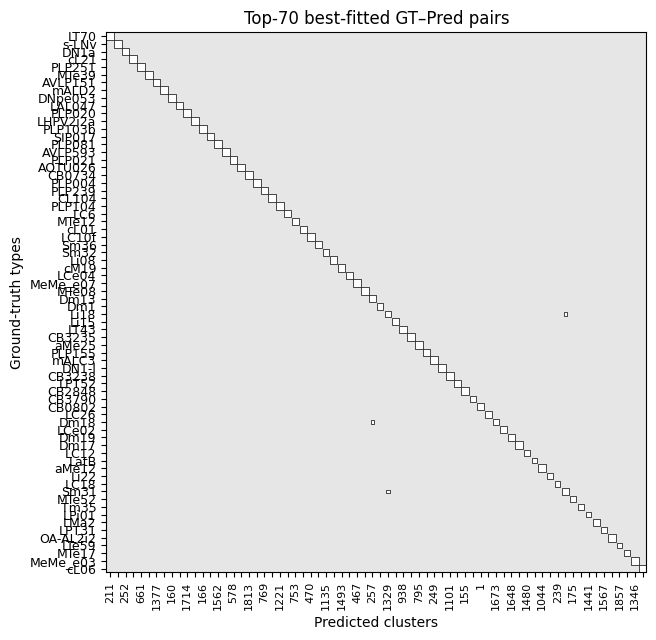

{'C': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(743, 1191)),
 'S': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(743, 1191)),
 'assignment_rows': array([167, 181, 539, 533, 485, 204, 304, 556, 290, 252, 483, 522, 555,
        675, 186, 649, 469, 385, 448, 583, 273, 261, 416, 586, 678, 381,
         17, 527, 696, 401,   9, 627, 604, 635, 196, 669, 729, 724, 282,
        694, 340, 400,   2, 588, 682, 148, 651, 605,  69, 626,  56, 108,
        296, 286, 554,  53, 541, 545, 234, 403, 715,  97, 152, 325, 206,
        276,  22, 368, 644,  12,   6, 664, 653, 100, 510,  82,  80, 179,
        157, 459, 374, 321, 357, 

In [277]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])



#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(sbm_assignments)


id_to_string = {v: k for k, v in cluster_string_to_cid.items()}
row_names = [id_to_string[i] for i in range(len(id_to_string))]

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=row_names, col_names=ro_names,
    normalize='row',
    score_metric='f1', 
    top_k_pairs=70,          
    corner='tr',             
    title='Top-70 best-fitted GT–Pred pairs',
    save_csv_path="sbm_top70_best_match.csv",
    filter_c=10,
    filter_f=0.5
)


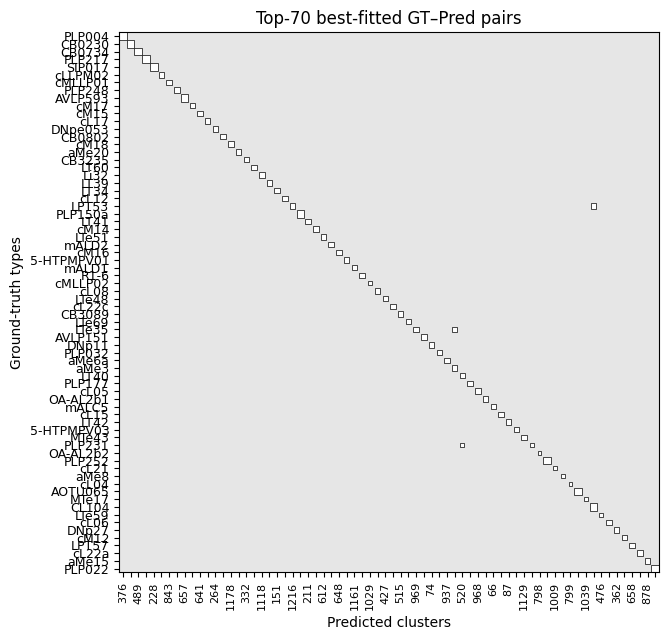

{'C': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(743, 1068)),
 'S': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(743, 1068)),
 'assignment_rows': array([583, 653, 448, 133, 675, 235, 404, 497, 649,  59, 434, 625, 290,
         69, 445, 288, 694, 382, 700, 240, 549, 287, 165, 716, 242, 330,
        711, 556, 173, 134, 319, 236, 309, 361, 414, 665, 331, 577, 256,
        304, 150, 568, 201, 179, 191, 593, 367, 610, 219, 685,  13, 370,
        684, 158, 285,  63, 533, 161, 642, 559, 368, 261,  22,  12, 739,
         62, 349, 660, 184, 306, 163, 249, 728, 271, 569, 475, 376, 534,
        558, 461,  93, 638, 146, 

In [276]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(pca_assignments)

plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=row_names, col_names=ro_names,
    normalize='row',
    score_metric='f1',
    top_k_pairs=70,
    corner='tr',
    title='Top-70 best-fitted GT–Pred pairs',
    save_csv_path="pca_top70_best_match.csv",
    filter_c=0,
    filter_f=0.5
)


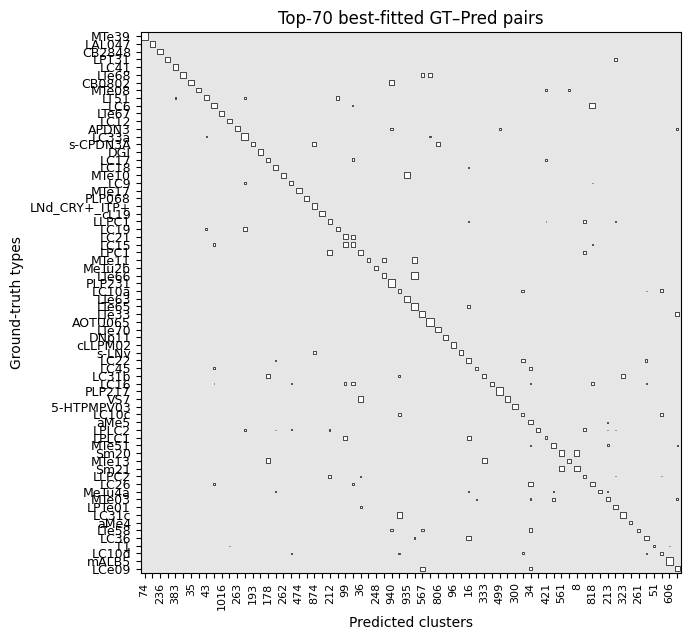

{'C': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(743, 542)),
 'S': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(743, 542)),
 'assignment_rows': array([204, 252, 651, 206,  83,  10,  69, 635, 297, 586, 244, 554, 455,
        472, 544, 510, 147, 234, 280, 466, 368, 321, 601, 542, 581, 677,
        397, 122, 111, 479, 529, 578, 158, 620, 719, 317, 562, 559, 313,
        150, 235, 181, 251, 535, 188, 633, 133, 135, 370, 115, 518, 458,
        654, 516, 443, 538, 430,  25, 626, 621, 293, 250, 390, 347, 710,
        345, 162, 471, 163, 412, 723, 166, 480, 508, 372, 192, 648, 517,
        718, 644, 441, 499, 457, 29

In [273]:
#1 compute gt
gt_assignments = np.array([cluster_string_to_cid[root_id_type_dict[rid]] for rid in shared_root_ids])

#2 random optimistic label
random_assignment_optimistic = np.random.permutation(gt_assignments)

#3 transfer to continuous int label
y_gt_i, gt_names = make_consecutive_labels(gt_assignments)
y_ro_i, ro_names = make_consecutive_labels(lv_assignments)


plot_hinton_gt_vs_pred(
    y_gt_i, y_ro_i,
    row_names=row_names, col_names=ro_names,
    normalize='row',
    score_metric='f1',
    top_k_pairs=70,
    corner='tr',
    title='Top-70 best-fitted GT–Pred pairs',
    save_csv_path="lv_top70_best_match.csv",
    filter_c=10,
    filter_f=0
)
